# Final plots bachelor project (part 2)
Created 2025-05-18

Summary of all the plots created for the bachelor thesis

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
import itertools
from typing import Literal

import matplotlib as mpl
from matplotlib.axes._axes import Axes
from matplotlib.figure import Figure
import matplotlib.patches

from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
import scipy

class bcolors:
    HEADER = '\033[95m'
    OKBLUE = '\033[94m'
    OKCYAN = '\033[96m'
    OKGREEN = '\033[92m'
    WARNING = '\033[93m'
    FAIL = '\033[91m'
    ENDC = '\033[0m'
    BOLD = '\033[1m'
    UNDERLINE = '\033[4m'


In [2]:
# Settings

# Path to resource folder with the structures and metadata tables
path_resources = Path(r"D:\Eigene Datein\dev\Uni\JGU Bio Bachelorthesis\Daten\resources")

path_AF2 = path_resources / "AF2"
path_AF3 = path_resources / "AF3_hydrogens"
path_solved = path_resources / "solved"

In [3]:
dataAF2 = pd.read_csv(path_AF2 / "AF2_metrics.tsv", sep="\t")
for c in ["chainA_start", "chainA_end", "chainB_start", "chainB_end", "num_mutations", "num_align_atoms_domain", "num_align_resi_domain", "hbonds", "salt_bridges", "hydrophobic_interactions"]:
    if c not in dataAF2.columns:
        print(f"Column {bcolors.FAIL}{c}{bcolors.ENDC} not (yet) in data frame")
        continue
    dataAF2[c] = dataAF2[c].astype(pd.Int64Dtype())
rank_columns = [
    ("score_rank", "model_confidence", False),
    ("RMSD_rank", "RMSD_all_atom", True),
    ("RMSD_peptide_rank", "RMSD_all_atom_peptide", True),
    ("DockQ_rank", "DockQ", False),
    ("intf_avg_plddt_rank", "intf_avg_plddt", False),
    ("chainA_intf_avg_plddt", "chainA_intf_avg_plddt", False),
    ("chainB_intf_avg_plddt_rank", "chainB_intf_avg_plddt", False),
    ("pDockQ_rank", "pDockQ", False),
    ("iPAE_rank", "iPAE", True),
]
for label, c, ascending in rank_columns:
    dataAF2[label] = dataAF2.groupby("prediction_name")[c].rank("first", ascending=ascending).astype(pd.Int64Dtype())

# dataAF2["score_rank"] = dataAF2.groupby("prediction_name")["model_confidence"].rank("first", ascending=False).astype(pd.Int64Dtype())
# dataAF2["RMSD_rank"] = dataAF2.groupby("prediction_name")["RMSD_all_atom"].rank("first").astype(pd.Int64Dtype())
# dataAF2["RMSD_peptide_rank"] = dataAF2.groupby("prediction_name")["RMSD_all_atom_peptide"].rank("first").astype(pd.Int64Dtype())
# dataAF2["DockQ_rank"] = dataAF2.groupby("prediction_name")["DockQ"].rank("first").astype(pd.Int64Dtype())
display(dataAF2)

,project_name,run_id,benchmark_set,prediction_name,model_id,chainA_length,chainB_length,chainA_id,chainB_id,chainA_start,...,hbonds,hydrophobic_interactions,score_rank,RMSD_rank,RMSD_peptide_rank,DockQ_rank,intf_avg_plddt_rank,chainB_intf_avg_plddt_rank,pDockQ_rank,iPAE_rank
0,AlphaFold_benchmark,run37,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_0,312,5,A,B,165,...,9,0,1,2,2,3,1,1,1,1
1,AlphaFold_benchmark,run37,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_1,312,5,A,B,165,...,9,0,2,3,1,2,2,2,2,2
2,AlphaFold_benchmark,run37,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_2,312,5,A,B,165,...,10,3,3,1,3,1,3,3,3,3
3,AlphaFold_benchmark,run37,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_3,312,5,A,B,165,...,2,0,4,4,4,4,4,4,4,4
4,AlphaFold_benchmark,run37,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_4,312,5,A,B,165,...,2,9,5,5,5,5,5,5,5,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3175,AlphaFold_benchmark_DDI,run6,random_DDI,D1PF18773_PF00071_2X19.D2PF00009_PF01873_2D74,ranked_0,60,113,B,B,392,...,7,56,1,1,<NA>,<NA>,4,4,2,1
3176,AlphaFold_benchmark_DDI,run6,random_DDI,D1PF18773_PF00071_2X19.D2PF00009_PF01873_2D74,ranked_1,60,113,B,B,392,...,3,7,2,5,<NA>,<NA>,3,3,3,2
3177,AlphaFold_benchmark_DDI,run6,random_DDI,D1PF18773_PF00071_2X19.D2PF00009_PF01873_2D74,ranked_2,60,113,B,B,392,...,2,11,3,4,<NA>,<NA>,5,5,5,3
3178,AlphaFold_benchmark_DDI,run6,random_DDI,D1PF18773_PF00071_2X19.D2PF00009_PF01873_2D74,ranked_3,60,113,B,B,392,...,7,44,4,3,<NA>,<NA>,1,1,4,4


In [4]:
dataAF3 = pd.read_csv(path_AF3 / f"{path_AF3.name}_metrics.tsv", sep="\t")
for c in ["chainA_start", "chainA_end", "chainB_start", "chainB_end", "num_mutations", "num_align_atoms_domain", "num_align_resi_domain", "hbonds", "salt_bridges", "hydrophobic_interactions"]:
    if c not in dataAF3.columns:
        print(f"Column {bcolors.FAIL}{c}{bcolors.ENDC} not (yet) in data frame")
        continue
    dataAF3[c] = dataAF3[c].astype(pd.Int64Dtype())
rank_columns = [
    ("score_rank", "ranking_score", False),
    ("RMSD_rank", "RMSD_all_atom", True),
    ("RMSD_peptide_rank", "RMSD_all_atom_peptide", True),
    ("DockQ_rank", "DockQ", False),
    ("intf_avg_plddt_rank", "intf_avg_plddt", False),
    ("chainA_intf_avg_plddt", "chainA_intf_avg_plddt", False),
    ("chainB_intf_avg_plddt_rank", "chainB_intf_avg_plddt", False),
    ("pDockQ_rank", "pDockQ", False),
    ("iPAE_rank", "iPAE", True),
]
for label, c, ascending in rank_columns:
    dataAF3[label] = dataAF3.groupby("prediction_name")[c].rank("first", ascending=ascending).astype(pd.Int64Dtype())
# dataAF3["score_rank"] = dataAF3.groupby("prediction_name")["ranking_score"].rank("first", ascending=False).astype(pd.Int64Dtype())
# dataAF3["RMSD_rank"] = dataAF3.groupby("prediction_name")["RMSD_all_atom"].rank("first").astype(pd.Int64Dtype())
# dataAF3["RMSD_peptide_rank"] = dataAF3.groupby("prediction_name")["RMSD_all_atom_peptide"].rank("first").astype(pd.Int64Dtype())
# dataAF3["DockQ_rank"] = dataAF3.groupby("prediction_name")["DockQ"].rank("first").astype(pd.Int64Dtype())
display(dataAF3)

,model_preset,benchmark_set,prediction_name,model_id,ranking_score,chainA_length,chainB_length,chainA_id,chainB_id,chainA_start,...,hydrophobic_interactions,ipSAE,score_rank,RMSD_rank,RMSD_peptide_rank,DockQ_rank,intf_avg_plddt_rank,chainB_intf_avg_plddt_rank,pDockQ_rank,iPAE_rank
0,alphafold3,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_0,0.97,312,5,A,B,165,...,0,0.869025,1,2,1,1,1,1,1,1
1,alphafold3,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_1,0.97,312,5,A,B,165,...,0,0.868551,2,3,3,3,2,2,2,2
2,alphafold3,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_2,0.96,312,5,A,B,165,...,0,0.855837,3,5,4,5,3,3,3,5
3,alphafold3,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_3,0.96,312,5,A,B,165,...,0,0.850758,4,1,2,2,5,5,5,3
4,alphafold3,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_4,0.96,312,5,A,B,165,...,0,0.850449,5,4,5,4,4,4,4,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3175,alphafold3,random_DDI,D1PF18773_PF00071_2X19.D2PF00009_PF01873_2D74,ranked_0,0.36,60,113,B,B,392,...,0,0.012324,1,1,<NA>,<NA>,2,2,3,1
3176,alphafold3,random_DDI,D1PF18773_PF00071_2X19.D2PF00009_PF01873_2D74,ranked_1,0.23,60,113,B,B,392,...,15,0.000000,2,5,<NA>,<NA>,1,1,4,2
3177,alphafold3,random_DDI,D1PF18773_PF00071_2X19.D2PF00009_PF01873_2D74,ranked_2,0.22,60,113,B,B,392,...,0,0.000000,3,4,<NA>,<NA>,5,5,5,4
3178,alphafold3,random_DDI,D1PF18773_PF00071_2X19.D2PF00009_PF01873_2D74,ranked_3,0.21,60,113,B,B,392,...,48,0.000000,4,3,<NA>,<NA>,4,4,2,3


In [5]:
dataSolved = pd.read_csv(path_solved / "solved_hydrogens_metrics.tsv", sep="\t")
display(dataSolved)

,set,PDB_id,DDI_pfam_id,path,chainA_id,chainB_id,min_distance,buried_area,salt_bridges,hbonds,disulfide_bonds,hydrophobic_interactions
0,DMI,1ATP,NaN,DMI_hydrogens\1ATP_min_DMI.pdb,A,B,6.273,808.592,0,1,0,77
1,DMI,1AXC,NaN,DMI_hydrogens\1AXC_min_DMI.pdb,A,B,4.174,1209.332,0,4,0,62
2,DMI,1B72,NaN,DMI_hydrogens\1B72_min_DMI.pdb,A,B,5.182,547.149,0,1,0,36
3,DMI,1B8Q,NaN,DMI_hydrogens\1B8Q_min_DMI.pdb,A,B,4.376,871.756,0,4,0,42
4,DMI,1BXX,NaN,DMI_hydrogens\1BXX_min_DMI.pdb,A,B,4.435,783.465,0,6,0,19
...,...,...,...,...,...,...,...,...,...,...,...,...
183,DDI,3ZNI,PF14447_PF00179,DDI_hydrogens\PF14447_PF00179_3ZNI_AC.pdb,A,C,5.268,1288.881,0,10,0,85
184,DDI,3J7Y,PF14978_PF00327,DDI_hydrogens\PF14978_PF00327_3J7Y_oZ.pdb,o,Z,4.885,2488.556,0,8,0,70
185,DDI,6D6Q,PF15985_PF10175,DDI_hydrogens\PF15985_PF10175_6D6Q_GL.pdb,G,L,3.891,3659.160,1,12,0,167
186,DDI,3KZ1,PF17838_PF00071,DDI_hydrogens\PF17838_PF00071_3KZ1_BE.pdb,B,E,5.276,1249.398,2,10,0,60


In [6]:
dataAF = pd.merge(
    left=dataAF3,
    right=dataAF2,
    left_on=["benchmark_set", "prediction_name", "model_id"],
    right_on=["benchmark_set", "prediction_name", "model_id"],
    suffixes=["_AF3", "_AF2"],
    how="inner"
)
for c in ["chainA_length", "chainB_length", "chainA_id", "chainB_id", "chainA_start", "chainA_end", "chainB_start", "chainB_end", "PDB_id", "ELM_instance", "DDI_pfam_id", "PDB_id_random_paired", "ELM_instance_random_paired", "DDI_pfam_id_random_paired", "sequence_initial", "sequence_mutated", "num_mutations", "score_rank"]:
    if len(dataAF[~(dataAF[c+"_AF2"] == dataAF[c+"_AF3"]) & (~dataAF[c+"_AF2"].isna()) & (~dataAF[c+"_AF3"].isna())]) > 0:
        print(f"Unmatched column {c}")
        continue
    dataAF.drop(columns=[c+"_AF2"], inplace=True)
    dataAF.rename(columns={c+"_AF3": c}, inplace=True)
dataAF.rename(columns={"ranking_score": "ranking_score_AF3"}, inplace=True)
dataAF.rename(columns={"model_confidence": "model_confidence_AF2"}, inplace=True)
dataAF.rename(columns={"ipSAE": "ipSAE_AF3"}, inplace=True)

display(dataAF)

,model_preset,benchmark_set,prediction_name,model_id,ranking_score_AF3,chainA_length,chainB_length,chainA_id,chainB_id,chainA_start,...,salt_bridges_AF2,hbonds_AF2,hydrophobic_interactions_AF2,RMSD_rank_AF2,RMSD_peptide_rank_AF2,DockQ_rank_AF2,intf_avg_plddt_rank_AF2,chainB_intf_avg_plddt_rank_AF2,pDockQ_rank_AF2,iPAE_rank_AF2
0,alphafold3,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_0,0.97,312,5,A,B,165,...,0,9,0,2,2,3,1,1,1,1
1,alphafold3,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_1,0.97,312,5,A,B,165,...,0,9,0,3,1,2,2,2,2,2
2,alphafold3,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_2,0.96,312,5,A,B,165,...,0,10,3,1,3,1,3,3,3,3
3,alphafold3,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_3,0.96,312,5,A,B,165,...,0,2,0,4,4,4,4,4,4,4
4,alphafold3,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_4,0.96,312,5,A,B,165,...,0,2,9,5,5,5,5,5,5,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3165,alphafold3,random_DDI,D1PF18773_PF00071_2X19.D2PF00009_PF01873_2D74,ranked_0,0.36,60,113,B,B,392,...,3,7,56,1,<NA>,<NA>,4,4,2,1
3166,alphafold3,random_DDI,D1PF18773_PF00071_2X19.D2PF00009_PF01873_2D74,ranked_1,0.23,60,113,B,B,392,...,0,3,7,5,<NA>,<NA>,3,3,3,2
3167,alphafold3,random_DDI,D1PF18773_PF00071_2X19.D2PF00009_PF01873_2D74,ranked_2,0.22,60,113,B,B,392,...,1,2,11,4,<NA>,<NA>,5,5,5,3
3168,alphafold3,random_DDI,D1PF18773_PF00071_2X19.D2PF00009_PF01873_2D74,ranked_3,0.21,60,113,B,B,392,...,3,7,44,3,<NA>,<NA>,1,1,4,4


In [7]:
# Loading icons
# import matplotlib.image as image
# from matplotlib.offsetbox import (OffsetImage, AnnotationBbox)

# img_rmsd_motif = image.imread("./icons/RMSD motif v6.png")
# img_rmsd_domain = image.imread("./icons/RMSD domain v6.png")

In [8]:
# Stop cell designed to crash to allow "Run All" command in Jupyter notebooks to stop here
raise Exception("STOP")

Exception: STOP

### 1 AF3 vs AF2

In [ ]:
def plot_af2_vs_af3_RMSD_per_structure(ax: Axes, set_: Literal["DMI", "DDI"], rmsd_categorie: Literal["all", "domain", "motif"], rank_filter: None|str|Literal["best_ranked", "RMSD", "RMSD_peptide", "DockQ"], sort_by: Literal["AF2", "AF3"]):
    af2_data = []
    af3_data = []
    match rmsd_categorie:
        case "all":
            rmsd_c = "RMSD_all_atom"
            ax.set_title("RMSD of the structure")
        case "domain":
            rmsd_c = "RMSD_domain"
            if set_ == "DMI":
                ax.set_title("RMSD of the domain")
            elif set_ == "DDI":
                ax.set_title("RMSD larger domain")
        case "motif":
            rmsd_c = "RMSD_all_atom_peptide"
            ax.set_title("RMSD of the motif")
            if set_ == "DMI":
                ax.set_title("RMSD of the motif")
            elif set_ == "DDI":
                ax.set_title("RMSD smaller domain")
        case _:
            raise RuntimeError(f"Unexpected rmsd_categorie")
    benchmark_set = f"known_{set_}"

    data_mask_AF2 = np.full(len(dataAF), fill_value=True)
    data_mask_AF3 = np.full(len(dataAF), fill_value=True)
    if rank_filter == "best_ranked":
        data_mask_AF2 = (dataAF[f"score_rank"] == 1)
        data_mask_AF3 = data_mask_AF2
    elif rank_filter is not None:
        data_mask_AF2 = (dataAF[f"{rank_filter}_rank_AF2"] == 1)
        data_mask_AF3 = (dataAF[f"{rank_filter}_rank_AF3"] == 1)
        rank_filter = rank_filter.replace("_", "") + "_ranked"

    for i, row in dataAF[(dataAF["benchmark_set"] == benchmark_set) & (data_mask_AF3 if sort_by == "AF3" else data_mask_AF2)].sort_values(by=f"{rmsd_c}_{sort_by}").iterrows():
        if sort_by == "AF2":
            af2_data.append(row[f"{rmsd_c}_AF2"])
            row_2 = dataAF[(dataAF["benchmark_set"] == benchmark_set) & (data_mask_AF3) & (dataAF["prediction_name"] == row["prediction_name"])]
            if len(row_2) != 1: raise RuntimeError
            af3_data.append(row_2[f"{rmsd_c}_AF3"].item())
        elif sort_by == "AF3":
            af3_data.append(row[f"{rmsd_c}_AF3"])
            row_2 = dataAF[(dataAF["benchmark_set"] == benchmark_set) & (data_mask_AF2) & (dataAF["prediction_name"] == row["prediction_name"])]
            if len(row_2) != 1: raise RuntimeError
            af2_data.append(row_2[f"{rmsd_c}_AF2"].item())
        

    ax.bar(range(len(af2_data)), af2_data, color="tab:green", label="AlphaFold 2")
    ax.bar(range(len(af3_data)), [-y for y in af3_data], color="tab:blue", label="AlphaFold 3")
    if sort_by == "AF3":
       ax.plot(range(len(af3_data)), af3_data, color="tab:blue")
       ax.plot(range(len(af3_data)), [-y for y in af3_data], color="tab:blue")
    elif sort_by == "AF2":
       ax.plot(range(len(af2_data)), af2_data, color="tab:green")
       ax.plot(range(len(af2_data)), [-y for y in af2_data], color="tab:green")

    ax.set_ylabel("RMSD [Å]")
    if set_ == "DDI":
        ax.set_xlabel(f"46 DDI predictions ordered by RMSD")
    elif set_ == "DMI":
        ax.set_xlabel(f"136 DMI predictions ordered by RMSD")
    ax.set_xticks([], [])
    x_label_patch = matplotlib.patches.Polygon([(0.95, -0.1), (0.95, -0.2), (0.05, -0.15),], color="silver", clip_on=False, transform=ax.transAxes)
    ax.add_patch(x_label_patch)
    ax.text(1, -0.15, "bad", transform=ax.transAxes, horizontalalignment="center", verticalalignment="center")
    ax.text(0, -0.15, "good", transform=ax.transAxes, horizontalalignment="center", verticalalignment="center")
    ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda y,pos:abs(y)))
    #ax.text(0.5, -0.22, "136 DMI predictions ordered", transform=ax.transAxes, horizontalalignment="center")

    #ab = AnnotationBbox(imagebox, xy=(0.5,-0.2), xycoords="axes fraction", frameon=False)
    #ax.add_artist(ab)

    return af2_data, af3_data

def stats_RMSD_result(text:str, af2_data, af3_data):
    af_domain_delta = np.array(af2_data) - np.array(af3_data)
    print(f"{text:<25}AF2\t\tAF3")
    print(f"  {'median':<23}{np.median(af2_data):1.3f}\t\t{np.median(af3_data):1.3f}")
    print(f"  {'best gap':<23}{np.max(-af_domain_delta):1.3f}\t\t{np.max(af_domain_delta):1.3f}")
    print(f"  {'median gap':<23}{np.median(af_domain_delta[af_domain_delta > 0]):1.3f}\t\t{np.median(af_domain_delta[af_domain_delta < 0]):1.3f}")
    print(f"  {'median gap AF3':<23}\t{np.median(af_domain_delta):1.3f}")
    print(f"  {'count lead':<23}{np.count_nonzero(af_domain_delta < 0)}\t\t{np.count_nonzero(af_domain_delta > 0)}")
    print(f"  {'count lead > 0.1':<23}{np.count_nonzero(af_domain_delta < -0.1)}\t\t{np.count_nonzero(af_domain_delta > 0.1)}")
    print(f"  {'count lead > 0.5':<23}{np.count_nonzero(af_domain_delta < -0.5)}\t\t{np.count_nonzero(af_domain_delta > 0.5)}")
    print(f"  {'count lead > 1':<23}{np.count_nonzero(af_domain_delta < -1)}\t\t{np.count_nonzero(af_domain_delta > 1)}")
    print(f"  {'count lead > 2.5':<23}{np.count_nonzero(af_domain_delta < -2.5)}\t\t{np.count_nonzero(af_domain_delta > 2.5)}")
    print(f"  {'count lead > 5':<23}{np.count_nonzero(af_domain_delta < -5)}\t\t{np.count_nonzero(af_domain_delta > 5)}")
    print(f"  {'AFx < 5, AFy >= 5':<23}{np.count_nonzero([(a2 < 5) and (a3 >= 5) for a2, a3 in zip(af2_data, af3_data)])}\t\t{np.count_nonzero([(a3 < 5) and (a2 >= 5) for a2, a3 in zip(af2_data, af3_data)])}")
    print(f"  {'AFx < 2, AFy >= 5':<23}{np.count_nonzero([(a2 < 2) and (a3 >= 5) for a2, a3 in zip(af2_data, af3_data)])}\t\t{np.count_nonzero([(a3 < 2) and (a2 >= 5) for a2, a3 in zip(af2_data, af3_data)])}")
    print(f"  {'AFx < 2, AFy >= 2':<23}{np.count_nonzero([(a2 < 2) and (a3 >= 2) for a2, a3 in zip(af2_data, af3_data)])}\t\t{np.count_nonzero([(a3 < 2) and (a2 >= 2) for a2, a3 in zip(af2_data, af3_data)])}")
    print(f"  {'AFx < 3, AFy >= 10':<23}{np.count_nonzero([(a2 < 3) and (a3 >= 10) for a2, a3 in zip(af2_data, af3_data)])}\t\t{np.count_nonzero([(a3 < 3) and (a2 >= 10) for a2, a3 in zip(af2_data, af3_data)])}")

def plot_RSMD_figure(set_: Literal["DMI", "DDI"], sort_by: Literal["AF2", "AF3"], rank_filter: None|str|Literal["best_ranked", "RMSD", "RMSD_peptide", "DockQ"], include_letter: str|None, save: bool, stats: bool):
    fig, axes = plt.subplots(1,2, figsize=(9,3))
    af2_a, af3_a = plot_af2_vs_af3_RMSD_per_structure(axes[0], set_=set_, rmsd_categorie="domain", sort_by=sort_by, rank_filter=rank_filter)
    af2_b, af3_b = plot_af2_vs_af3_RMSD_per_structure(axes[1], set_=set_, rmsd_categorie="motif", sort_by=sort_by, rank_filter=rank_filter)
    axes[0].legend(frameon=False)
    if include_letter is not None:
        fig.text(0.02,0.89, "C", fontsize=18)
    fig.tight_layout()   
    fig.suptitle(f"Aligning the {'larger ' if set_== 'DDI' else ''}domain", y=1)
    if save:
        plt.savefig(f"./plots/{set_}_RMSD_comparison{'_sorted_by_AF2' if sort_by == 'AF2' else ''}{f'_{rank_filter}_ranked' if rank_filter is not None else ''}.png", bbox_inches='tight', dpi=600)
    plt.show()
    if stats:
        if set_ == "DMI":
            stats_RMSD_result("RMSD of domain (DMI)", af2_a, af3_a)
            stats_RMSD_result("RMSD of motif (DMI)", af2_b, af3_b)
        elif set_ == "DDI":
            stats_RMSD_result("RMSD of larger domain (DDI)", af2_a, af3_a)
            stats_RMSD_result("relative RMSD of smaller domain (DDI)", af2_b, af3_b)
    return ((af2_a, af3_a), (af2_b, af3_b))

def plot_overall_RMSD(sort_by: Literal["AF2", "AF3"], rank_filter: None|str|Literal["best_ranked", "RMSD", "RMSD_peptide", "DockQ"],  save: bool, stats: bool):
    fig, axes = plt.subplots(1,2, figsize=(9,3))
    af2_a, af3_a = plot_af2_vs_af3_RMSD_per_structure(axes[0], set_="DMI", rmsd_categorie="all", sort_by=sort_by, rank_filter=rank_filter)
    af2_b, af3_b = plot_af2_vs_af3_RMSD_per_structure(axes[1], set_="DDI", rmsd_categorie="all", sort_by=sort_by, rank_filter=rank_filter)
    axes[0].legend(frameon=False)
    fig.tight_layout()
    if save:
        plt.savefig(f"./plots/RMSD_all_comparison{'_sorted_by_AF2' if sort_by == 'AF2' else ''}{f'_{rank_filter}_ranked' if rank_filter is not None else ''}.png", bbox_inches='tight', dpi=600)
    plt.show()
    if stats:
        stats_RMSD_result("RMSD all DMI", af2_a, af3_a)
        stats_RMSD_result("RMSD all DDI", af2_b, af3_b)
    return ((af2_a, af3_a), (af2_b, af3_b))

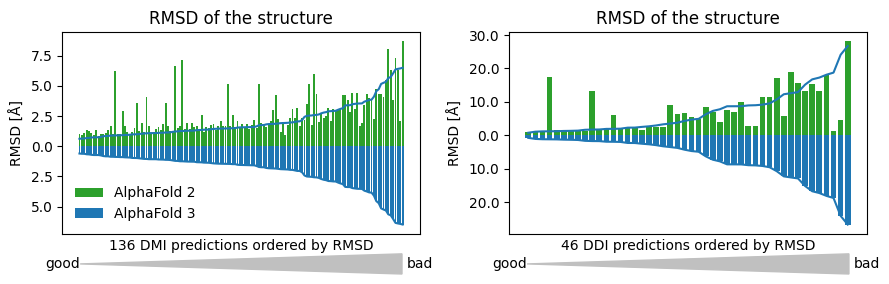

RMSD all DMI             AF2		AF3
  median                 1.877		1.557
  best gap               4.357		5.881
  median gap             0.363		-0.400
  median gap AF3         	0.243
  count lead             30		106
  count lead > 0.1       27		94
  count lead > 0.5       13		44
  count lead > 1         6		21
  count lead > 2.5       1		9
  count lead > 5         0		3
  AFx < 5, AFy >= 5      4		7
  AFx < 2, AFy >= 5      0		5
  AFx < 2, AFy >= 2      5		21
  AFx < 3, AFy >= 10     0		0
RMSD all DDI             AF2		AF3
  median                 5.147		4.504
  best gap               19.583		16.233
  median gap             1.685		-0.979
  median gap AF3         	0.059
  count lead             22		24
  count lead > 0.1       19		21
  count lead > 0.5       14		15
  count lead > 1         11		14
  count lead > 2.5       7		8
  count lead > 5         5		5
  AFx < 5, AFy >= 5      5		7
  AFx < 2, AFy >= 5      1		3
  AFx < 2, AFy >= 2      2		4
  AFx < 3, AFy >= 10     1		2


In [ ]:
_ = plot_overall_RMSD(sort_by="AF3", rank_filter="RMSD", save=True, stats=True)

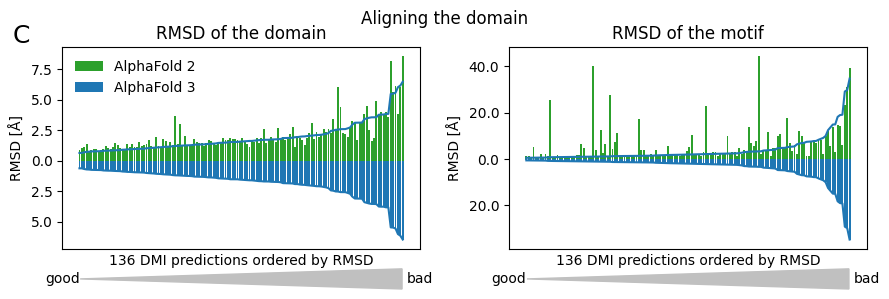

RMSD of domain (DMI)     AF2		AF3
  median                 1.697		1.563
  best gap               2.162		3.474
  median gap             0.207		-0.176
  median gap AF3         	0.142
  count lead             37		99
  count lead > 0.1       24		76
  count lead > 0.5       8		21
  count lead > 1         5		9
  count lead > 2.5       0		2
  count lead > 5         0		0
  AFx < 5, AFy >= 5      1		1
  AFx < 2, AFy >= 5      0		0
  AFx < 2, AFy >= 2      7		7
  AFx < 3, AFy >= 10     0		0
RMSD of motif (DMI)      AF2		AF3
  median                 2.704		1.962
  best gap               13.036		41.009
  median gap             0.665		-0.752
  median gap AF3         	0.290
  count lead             33		103
  count lead > 0.1       27		93
  count lead > 0.5       22		59
  count lead > 1         15		40
  count lead > 2.5       11		29
  count lead > 5         7		19
  AFx < 5, AFy >= 5      6		24
  AFx < 2, AFy >= 5      2		12
  AFx < 2, AFy >= 2      6		27
  AFx < 3, AFy >= 10     0		8


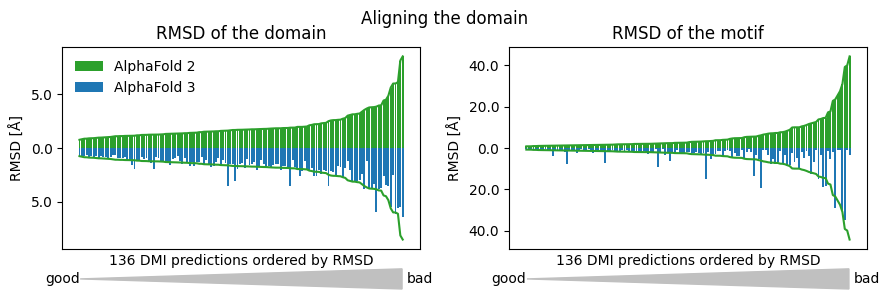

In [ ]:
((af2_RMSD_domain, af3_RMSD_domain), (af2_RMSD_motif, af3_RMSD_motif)) = plot_RSMD_figure(set_="DMI", sort_by="AF3", rank_filter="RMSD_peptide", include_letter="C", save=True, stats=True)
_ = plot_RSMD_figure(set_="DMI", sort_by="AF2", rank_filter="RMSD_peptide", include_letter=None, save=True, stats=False)

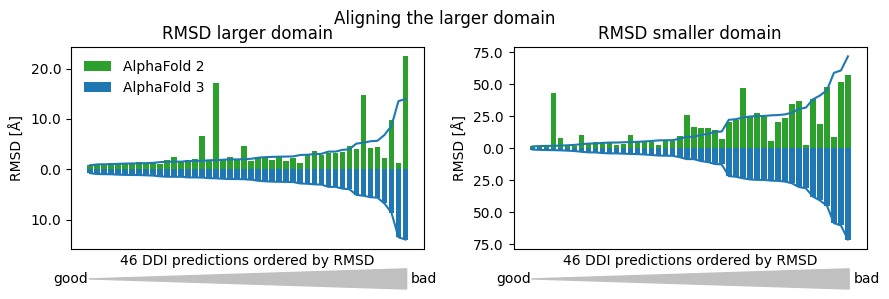

RMSD of larger domain (DDI)AF2		AF3
  median                 2.136		2.033
  best gap               12.194		15.305
  median gap             0.309		-0.308
  median gap AF3         	0.005
  count lead             23		23
  count lead > 0.1       18		17
  count lead > 0.5       8		9
  count lead > 1         6		6
  count lead > 2.5       2		5
  count lead > 5         1		3
  AFx < 5, AFy >= 5      5		2
  AFx < 2, AFy >= 5      1		2
  AFx < 2, AFy >= 2      5		6
  AFx < 3, AFy >= 10     1		1
relative RMSD of smaller domain (DDI)AF2		AF3
  median                 9.535		8.707
  best gap               50.372		41.608
  median gap             2.124		-1.594
  median gap AF3         	0.050
  count lead             22		24
  count lead > 0.1       20		22
  count lead > 0.5       17		17
  count lead > 1         14		16
  count lead > 2.5       10		11
  count lead > 5         8		10
  AFx < 5, AFy >= 5      3		6
  AFx < 2, AFy >= 5      1		2
  AFx < 2, AFy >= 2      2		2
  AFx < 3, AFy >= 10     1		2


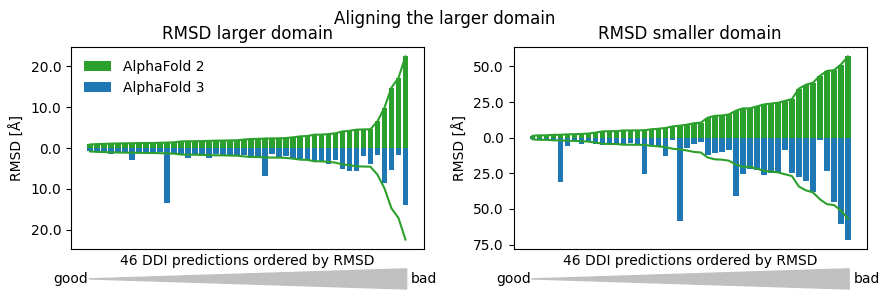

In [ ]:
_ = plot_RSMD_figure(set_="DDI", sort_by="AF3", rank_filter="RMSD_peptide", include_letter=None, save=True, stats=True)
_ = plot_RSMD_figure(set_="DDI", sort_by="AF2", rank_filter="RMSD_peptide", include_letter=None, save=True, stats=False)

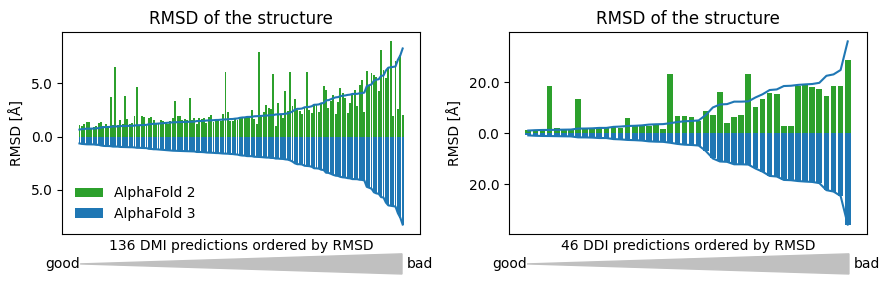

RMSD all DMI             AF2		AF3
  median                 1.979		1.769
  best gap               6.241		5.976
  median gap             0.479		-0.237
  median gap AF3         	0.208
  count lead             44		92
  count lead > 0.1       32		82
  count lead > 0.5       16		45
  count lead > 1         9		20
  count lead > 2.5       3		9
  count lead > 5         1		2
  AFx < 5, AFy >= 5      4		9
  AFx < 2, AFy >= 5      1		3
  AFx < 2, AFy >= 2      3		14
  AFx < 3, AFy >= 10     0		0
RMSD all DDI             AF2		AF3
  median                 6.124		4.647
  best gap               15.675		19.372
  median gap             1.433		-1.784
  median gap AF3         	-0.246
  count lead             28		18
  count lead > 0.1       27		15
  count lead > 0.5       18		11
  count lead > 1         17		10
  count lead > 2.5       11		6
  count lead > 5         8		5
  AFx < 5, AFy >= 5      3		7
  AFx < 2, AFy >= 5      0		2
  AFx < 2, AFy >= 2      1		3
  AFx < 3, AFy >= 10     2		2


In [ ]:
_ = plot_overall_RMSD(sort_by="AF3", rank_filter="best_ranked", save=True, stats=True)

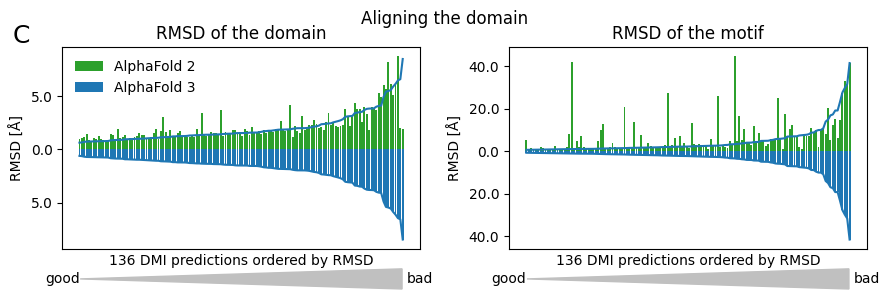

RMSD of domain (DMI)     AF2		AF3
  median                 1.700		1.523
  best gap               6.619		2.687
  median gap             0.277		-0.177
  median gap AF3         	0.104
  count lead             48		88
  count lead > 0.1       30		70
  count lead > 0.5       11		25
  count lead > 1         3		10
  count lead > 2.5       2		1
  count lead > 5         1		0
  AFx < 5, AFy >= 5      2		2
  AFx < 2, AFy >= 5      2		0
  AFx < 2, AFy >= 2      5		8
  AFx < 3, AFy >= 10     0		0
RMSD of motif (DMI)      AF2		AF3
  median                 3.073		2.254
  best gap               12.773		41.299
  median gap             0.676		-0.331
  median gap AF3         	0.250
  count lead             44		92
  count lead > 0.1       34		81
  count lead > 0.5       20		54
  count lead > 1         15		39
  count lead > 2.5       11		29
  count lead > 5         8		20
  AFx < 5, AFy >= 5      4		24
  AFx < 2, AFy >= 5      3		9
  AFx < 2, AFy >= 2      6		19
  AFx < 3, AFy >= 10     1		7


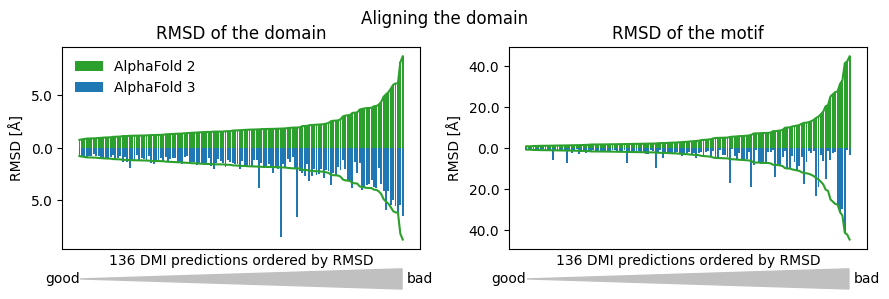

In [ ]:
_ = plot_RSMD_figure(set_="DMI", sort_by="AF3", rank_filter="best_ranked", include_letter="C", save=True, stats=True)
_ = plot_RSMD_figure(set_="DMI", sort_by="AF2", rank_filter="best_ranked", include_letter=None, save=True, stats=False)

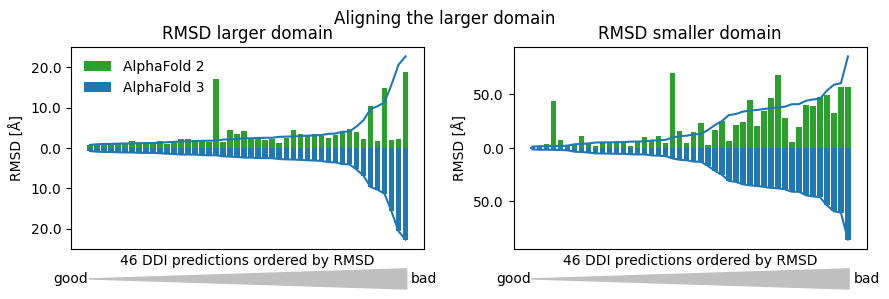

RMSD of larger domain (DDI)AF2		AF3
  median                 2.211		2.395
  best gap               18.418		15.305
  median gap             0.496		-0.359
  median gap AF3         	0.048
  count lead             21		25
  count lead > 0.1       19		19
  count lead > 0.5       9		12
  count lead > 1         8		6
  count lead > 2.5       5		2
  count lead > 5         3		1
  AFx < 5, AFy >= 5      5		1
  AFx < 2, AFy >= 5      2		1
  AFx < 2, AFy >= 2      4		3
  AFx < 3, AFy >= 10     3		1
relative RMSD of smaller domain (DDI)AF2		AF3
  median                 13.156		12.109
  best gap               35.748		60.477
  median gap             4.212		-3.821
  median gap AF3         	-0.445
  count lead             28		18
  count lead > 0.1       26		17
  count lead > 0.5       22		14
  count lead > 1         22		14
  count lead > 2.5       19		12
  count lead > 5         12		8
  AFx < 5, AFy >= 5      6		3
  AFx < 2, AFy >= 5      1		2
  AFx < 2, AFy >= 2      1		3
  AFx < 3, AFy >= 10     1		1
[

C:\Users\abril\AppData\Local\Temp\ipykernel_207516\2677435752.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(([f"{af2_domain1[int(i)]:1.3f}" for i in np.argwhere(np.array(af3_domain1) > 10)]))


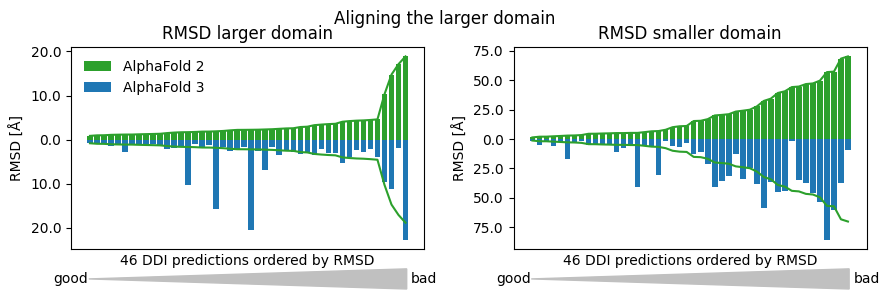

In [ ]:
(af2_domain1, af3_domain1), (af2_domain2, af3_domain2) = plot_RSMD_figure(set_="DDI", sort_by="AF3", rank_filter="best_ranked", include_letter=None, save=True, stats=True)
print(([f"{af2_domain1[int(i)]:1.3f}" for i in np.argwhere(np.array(af3_domain1) > 10)]))
_ = plot_RSMD_figure(set_="DDI", sort_by="AF2", rank_filter="best_ranked", include_letter=None, save=True, stats=False)

Manual inspection

In [ ]:
af3_RMSD_domain

[0.6306385397911072,
 0.6330022811889648,
 0.6884331107139587,
 0.7223315238952637,
 0.7300674915313721,
 0.7552458643913269,
 0.7605390548706055,
 0.7677798271179199,
 0.7690073847770691,
 0.7747114896774292,
 0.8049983978271484,
 0.8152598142623901,
 0.8223444819450378,
 0.824763834476471,
 0.8392056226730347,
 0.847247838973999,
 0.8555376529693604,
 0.8619468212127686,
 0.8928688168525696,
 0.902505338191986,
 0.9213528633117676,
 0.9258242845535278,
 0.9401770234107972,
 0.9528259038925172,
 0.9567477107048036,
 0.9661314487457277,
 0.9711576700210572,
 0.98088538646698,
 1.011771559715271,
 1.0299088954925537,
 1.0404945611953735,
 1.05292809009552,
 1.0777456760406494,
 1.084112524986267,
 1.0975556373596191,
 1.121073603630066,
 1.129738450050354,
 1.134513020515442,
 1.1524653434753418,
 1.1865649223327637,
 1.2045423984527588,
 1.2083516120910645,
 1.2220654487609863,
 1.2267712354660034,
 1.2421294450759888,
 1.2541548013687134,
 1.2587894201278689,
 1.2728123664855957,
 1.3

In [ ]:
_merge = pd.merge(
    left=dataAF[(dataAF["benchmark_set"] == "known_DMI")],
    right=dataAF[(dataAF["benchmark_set"] == "known_DMI")],
    left_on=["prediction_name", "benchmark_set", "RMSD_peptide_rank_AF2"],
    right_on=["prediction_name", "benchmark_set", "RMSD_peptide_rank_AF3"],
    suffixes=["_c1", "_c2"]
)
_merge["delta_RMSD_domain"] = _merge.apply(lambda r: r["RMSD_domain_AF2_c1"] - r["RMSD_domain_AF3_c2"], axis=1)
_merge["delta_RMSD_peptide"] = _merge.apply(lambda r: r["RMSD_all_atom_peptide_AF2_c1"] - r["RMSD_all_atom_peptide_AF3_c2"], axis=1)
_merge = _merge[_merge["RMSD_peptide_rank_AF2_c1"] == 1][["prediction_name", "benchmark_set", "model_id_c1", "model_id_c2", "delta_RMSD_domain", "delta_RMSD_peptide", "RMSD_all_atom_peptide_AF2_c1", "RMSD_all_atom_peptide_AF3_c2", "RMSD_domain_AF2_c1", "RMSD_domain_AF3_c2"]]
_merge.sort_values("delta_RMSD_peptide")

,prediction_name,benchmark_set,model_id_c1,model_id_c2,delta_RMSD_domain,delta_RMSD_peptide,RMSD_all_atom_peptide_AF2_c1,RMSD_all_atom_peptide_AF3_c2,RMSD_domain_AF2_c1,RMSD_domain_AF3_c2
171,LIG_AP2alpha_2_1KYU,known_DMI,ranked_1,ranked_1,-0.134562,-13.036160,6.129632,19.165792,1.966667,2.101228
513,LIG_RPA_C_Vert_1DPU,known_DMI,ranked_3,ranked_2,0.111850,-11.712016,3.266222,14.978238,1.725188,1.613338
28,DEG_SCF_COI1_1_3OGL,known_DMI,ranked_3,ranked_4,0.193607,-8.253320,5.489234,13.742555,1.856764,1.663157
481,LIG_PROFILIN_1_2V8C,known_DMI,ranked_1,ranked_4,0.108295,-7.026125,2.138828,9.164953,0.863541,0.755246
337,LIG_KLC1_WD_1_3ZFW,known_DMI,ranked_2,ranked_3,0.162675,-6.317023,1.207530,7.524553,1.692929,1.530254
...,...,...,...,...,...,...,...,...,...,...
249,LIG_CORNRBOX_1KKQ,known_DMI,ranked_4,ranked_4,-0.279672,20.675103,22.804068,2.128964,1.427610,1.707282
129,DOC_PP1_SILK_1_2O8G,known_DMI,ranked_4,ranked_2,-0.047261,24.753423,25.523716,0.770293,1.005667,1.052928
308,LIG_FAT_LD_1_3GM1,known_DMI,ranked_3,ranked_3,1.790592,26.347189,27.508253,1.161064,3.012658,1.222065
176,LIG_APCC_ABBA_1_4BH6,known_DMI,ranked_1,ranked_2,-0.004572,38.959712,40.003876,1.044164,0.897933,0.902505


For the domain AF3 is better for 25 structures and AF2 for 21 structures
	When setting 0.5 as threshold, the counts reduces to 12 for AF3 and 34 for AF2
	Both below th: 25
	AF3 max lead: 15.305
	AF2 max lead: -18.418
For the domain AF3 is better for 18 structures and AF2 for 28 structures
	When setting 0.5 as threshold, the counts reduces to 14 for AF3 and 32 for AF2
	Both below th: 10
	AF3 max lead: 60.477
	AF2 max lead: -35.748


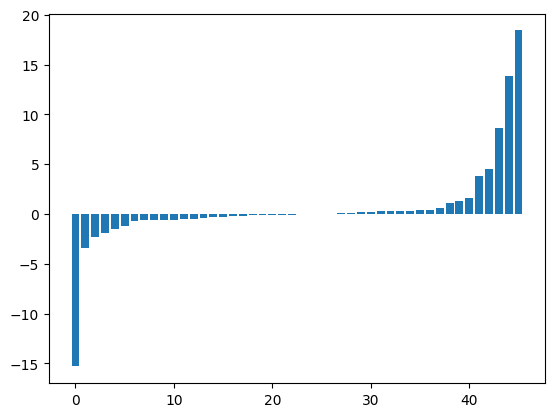

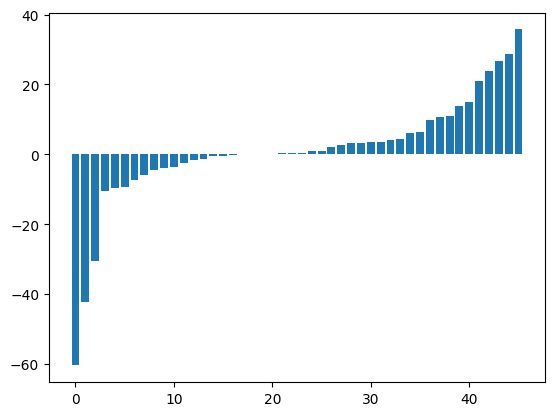

In [ ]:
# DDI analyzations
af_domain1_delta = np.array(af2_domain1) - np.array(af3_domain1)
print(f"For the domain AF3 is better for {np.count_nonzero(af_domain1_delta > 0)} structures and AF2 for {np.count_nonzero(af_domain1_delta < 0)} structures")
th = 0.5
print(f"\tWhen setting {th} as threshold, the counts reduces to {np.count_nonzero(af_domain1_delta > th)} for AF3 and {np.count_nonzero(af_domain1_delta < th)} for AF2")
print(f"\tBoth below th: {np.count_nonzero(np.abs(af_domain1_delta) < th)}")
print(f"\tAF3 max lead: {np.max(af_domain1_delta):1.3f}")
print(f"\tAF2 max lead: {np.min(af_domain1_delta):1.3f}")

af_domain2_delta = np.array(af2_domain2) - np.array(af3_domain2)
print(f"For the domain AF3 is better for {np.count_nonzero(af_domain2_delta > 0)} structures and AF2 for {np.count_nonzero(af_domain2_delta < 0)} structures")
th = 0.5
print(f"\tWhen setting {th} as threshold, the counts reduces to {np.count_nonzero(af_domain2_delta > th)} for AF3 and {np.count_nonzero(af_domain2_delta < th)} for AF2")
print(f"\tBoth below th: {np.count_nonzero(np.abs(af_domain2_delta) < th)}")
print(f"\tAF3 max lead: {np.max(af_domain2_delta):1.3f}")
print(f"\tAF2 max lead: {np.min(af_domain2_delta):1.3f}")

plt.bar(range(len(af_domain1_delta)), sorted(-af_domain1_delta))
plt.show()
plt.bar(range(len(af_domain2_delta)), sorted(-af_domain2_delta))
plt.show()

### 2 Anti-correlation of motif RMSD



(8, 8)


AttributeError: 'Axes' object has no attribute 'cmap'

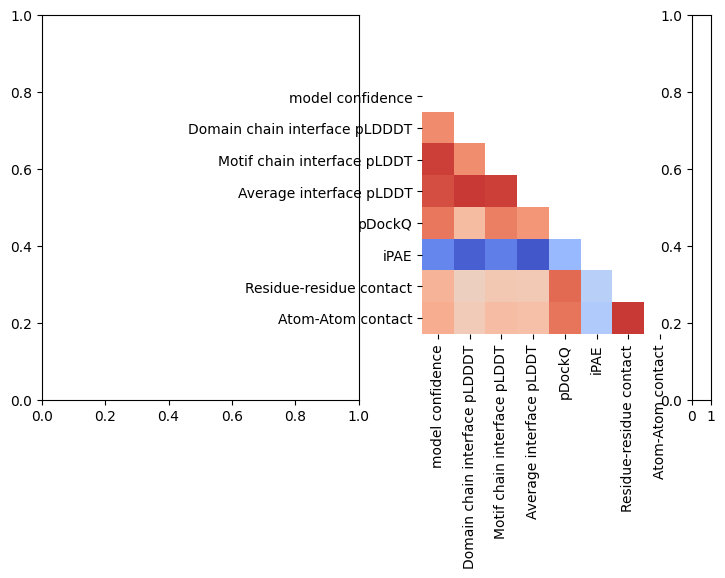

In [ ]:
def plot_motif_RMSD_correlation(ax:Axes, af_v: Literal["AF2", "AF3"], model_filter: bool, save: bool):
    metric_columns = [("model confidence", "model_confidence") if af_v == "AF2" else ("ranking_score", "ranking_score") ,
        ("Domain chain interface pLDDDT", "chainA_intf_avg_plddt"),
        ("Motif chain interface pLDDT", "chainB_intf_avg_plddt"),
        ("Average interface pLDDT", "intf_avg_plddt"),
        ("pDockQ", "pDockQ"),
        ("iPAE", "iPAE"),
        ("Residue-residue contact", "num_res_res_contact"),
        ("Atom-Atom contact", "num_atom_atom_contact"),
    ]
    metric_columns = [[x[0], x[1] + "_"+af_v] for x in metric_columns]

    data_mask = True
    if model_filter:
        data_mask &= (dataAF["model_id"] == "ranked_0")

    data = dataAF[(dataAF["benchmark_set"] == "known_DMI") & data_mask]

    data_vector = [data[c] for label, c in metric_columns]
    cor_matrix = np.corrcoef(data_vector, rowvar=True)
    print(cor_matrix.shape)
    for m in range(len(data_vector)):
        for n in range(m+1):
            cor_matrix[n,m] = None
    ax.imshow(cor_matrix, cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_xticks(range(len(metric_columns)), [label for label, c in metric_columns], rotation=90)
    ax.set_yticks(range(len(metric_columns)), [label for label, c in metric_columns])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)

    plt.colorbar(ax)
    
    for y, (label_y, column_y) in enumerate(metric_columns):
        for x, (label_x, column_x) in enumerate(metric_columns[:y]):
            pass

fig, axes = plt.subplots(1,2,figsize=(9,5))
plot_motif_RMSD_correlation(axes[1], af_v="AF2", model_filter=True, save=False)
plt.show()

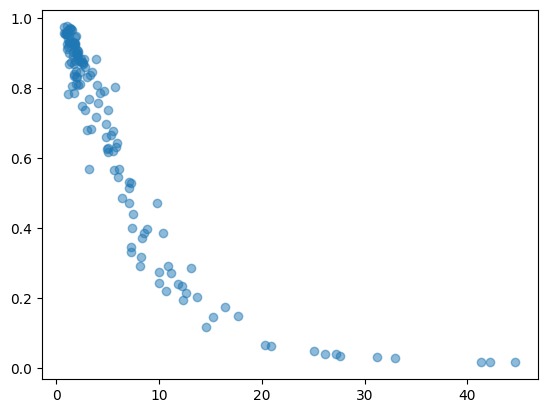

In [ ]:
d = dataAF[(dataAF["benchmark_set"] == "known_DMI") & (dataAF["model_id"] == "ranked_0")]
plt.scatter(d["RMSD_all_atom_peptide_AF2"], d["DockQ_AF2"], alpha=0.5)
plt.show()

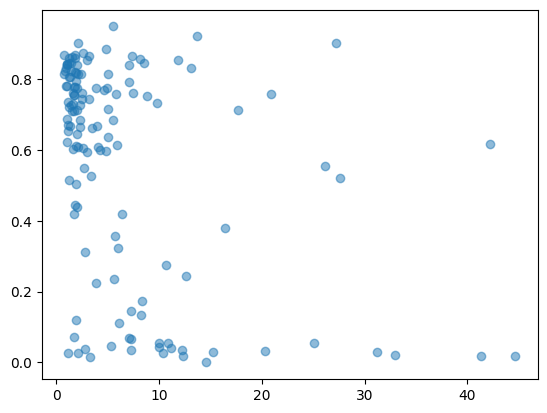

In [ ]:
d = dataAF[(dataAF["benchmark_set"] == "known_DMI") & (dataAF["model_id"] == "ranked_0")]
plt.scatter(d["RMSD_all_atom_peptide_AF2"], d["ipSAE_AF3"], alpha=0.5)
plt.show()

### 3 cutoff values

In [10]:
def get_roc(af_v: Literal["AF2", "AF3"], comparison:Literal["random_DMI", "random_DDI"], metric_column: str, reverse:bool, model_filter: bool, rmsd_filter: float|None):
    data_mask = True
    if model_filter:
        data_mask &= (dataAF["model_id"] == "ranked_0")
    if rmsd_filter:
        data_mask &= (dataAF[f"RMSD_all_atom_peptide_{af_v}"] <= rmsd_filter)
    match comparison:
        case "random_DMI":
            rows_true = dataAF[(dataAF["benchmark_set"] == "known_DMI") & data_mask]
            rows_false = dataAF[(dataAF["benchmark_set"] == "random_DMI") & data_mask]
        case "random_DDI":
            rows_true = dataAF[(dataAF["benchmark_set"] == "known_DDI") & data_mask]
            rows_false = dataAF[(dataAF["benchmark_set"] == "random_DDI") & data_mask]
        case _:
            raise RuntimeError("Invalid comparison parameter")
        
    tr = rows_true[metric_column+"_"+af_v].dropna()
    fa = rows_false[metric_column+"_"+af_v].dropna()
    y_true = [1]*len(tr) + [0]*len(fa) if not reverse else [0]*len(tr) + [1]*len(fa)
    y_score = tr.to_list() + fa.to_list()
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    # Assume all metrics from 0 to 1
    thresholds = np.nan_to_num(thresholds, posinf=1)
    fpr, tpr, thresholds = np.append(fpr, 1), np.append(tpr, 1), np.append(thresholds, 0)
    return fpr, tpr, thresholds


def plot_tpr_and_fpr(ax: Axes, tpr, fpr, thresholds, metric_label:str, cutoffs: list, legend:bool, title: str):
    ax.plot(thresholds, tpr, label="True positive rate")
    ax.plot(thresholds, (1-fpr), label="True negative rate")
    ax.set_xlabel(f"{metric_label} cutoff value")
    ax.set_ylabel("rate")
    for (cutoff_index, label, marker) in cutoffs:
        t = thresholds[cutoff_index]
        ax.scatter([t, t], [tpr[cutoff_index], (1-fpr)[cutoff_index]], marker=marker, c="red", label=label)
        ax.plot([t,t], [max(tpr[cutoff_index], (1-fpr)[cutoff_index]), 0], c="red", linestyle="dotted")
        ax.annotate(f"{t:1.2f}", (t, max(tpr[cutoff_index], (1-fpr)[cutoff_index])/3), rotation=-90, c="red")
        ax.annotate(f"{tpr[cutoff_index]:1.2f}", (t+0.03, tpr[cutoff_index]), c="tab:blue", verticalalignment="center")
        ax.annotate(f"{(1-fpr)[cutoff_index]:1.2f}", (t+0.03, (1-fpr)[cutoff_index]), c="tab:orange", verticalalignment="center")
        #ax.plot(thresholds[cutoff_left_index: cutoff_right_index+1], tpr[cutoff_left_index: cutoff_right_index+1], c="red")
        #ax.plot(thresholds[cutoff_left_index: cutoff_right_index+1], (1-fpr)[cutoff_left_index: cutoff_right_index+1], c="red")
        #ax.errorbar([thresholds[cutoff_index], thresholds[cutoff_index]], [tpr[cutoff_index], (1-fpr)[cutoff_index]], marker="+", c="red", yerr=None, xerr=[(xerr[i], xerr[i]) for i in range(2)], linestyle=None, label="optimal cutoff")
    ax.set_xlim([0,1])
    ax.set_ylim([0,1])
    ax.set_title(title)
    if legend:
        ax.legend()

def plot_cutoff_plot(af_v: Literal["AF2", "AF3"], metric_column: str, label:str, reverse:bool, model_filter: bool, rmsd_filter: float|None, save: bool, letter:str|None):
    fig, axes = plt.subplots(1,2, figsize=(9,3))
    fpr, tpr, thresholds = get_roc(af_v=af_v, comparison="random_DMI", metric_column=metric_column, reverse=reverse, model_filter=model_filter, rmsd_filter=rmsd_filter)
    optimal_cutoff = np.argmin(np.sqrt((1-tpr)**2+(fpr)**2))
    print("DMI")
    print(f"\tlinear method: {thresholds[np.argmax(tpr+(1-fpr))]:1.2f}")
    print(f"\tROC minimizing: {thresholds[np.argmin(np.sqrt((1-tpr)**2 + fpr**2))]:1.2f}")
    print(f"\tROC maximizing: {thresholds[np.argmax(np.sqrt(tpr**2 + (1-fpr)**2))]:1.2f}")
    plot_tpr_and_fpr(ax=axes[0], tpr=tpr, fpr=fpr, thresholds=thresholds, metric_label=label, cutoffs=[(optimal_cutoff, "optimal cutoff", "+")], legend=True, title="known vs. randomly paired DMI")
    fpr, tpr, thresholds = get_roc(af_v=af_v, comparison="random_DDI", metric_column=metric_column, reverse=reverse, model_filter=model_filter, rmsd_filter=rmsd_filter)
    optimal_cutoff = np.argmin(np.sqrt((1-tpr)**2+(fpr)**2))
    print("DDI")
    print(f"\tlinear method: {thresholds[np.argmax(tpr+(1-fpr))]:1.2f}")
    print(f"\tROC minimizing: {thresholds[np.argmin(np.sqrt((1-tpr)**2 + fpr**2))]:1.2f}")
    print(f"\tROC maximizing: {thresholds[np.argmax(np.sqrt(tpr**2 + (1-fpr)**2))]:1.2f}")
    plot_tpr_and_fpr(ax=axes[1], tpr=tpr, fpr=fpr, thresholds=thresholds, metric_label=label, cutoffs=[(optimal_cutoff, "optimal cutoff", "+")], legend=False, title="known vs. randomly paired DDI")
    fig.suptitle(f"Optimal cutoff for {label} (AlphaFold {3 if af_v=='AF3' else 2})", y=0.93)
    fig.tight_layout()
    if letter is not None:
        fig.text(0.03, 0.85, letter, fontsize=18)
    if save:
        plt.savefig(f"./plots/{af_v}_cutoff_{metric_column}{'_model_filter' if model_filter else ''}{f'_RMSD_{rmsd_filter}' if rmsd_filter else ''}.png", bbox_inches='tight', dpi=600)
    plt.plot()

In [ ]:
dataAF

,model_preset,benchmark_set,prediction_name,model_id,ranking_score_AF3,chainA_length,chainB_length,chainA_id,chainB_id,chainA_start,...,salt_bridges_AF2,hbonds_AF2,hydrophobic_interactions_AF2,RMSD_rank_AF2,RMSD_peptide_rank_AF2,DockQ_rank_AF2,intf_avg_plddt_rank_AF2,chainB_intf_avg_plddt_rank_AF2,pDockQ_rank_AF2,iPAE_rank_AF2
0,alphafold3,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_0,0.97,312,5,A,B,165,...,0,9,0,2,2,3,1,1,1,1
1,alphafold3,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_1,0.97,312,5,A,B,165,...,0,9,0,3,1,2,2,2,2,2
2,alphafold3,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_2,0.96,312,5,A,B,165,...,0,10,3,1,3,1,3,3,3,3
3,alphafold3,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_3,0.96,312,5,A,B,165,...,0,2,0,4,4,4,4,4,4,4
4,alphafold3,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_4,0.96,312,5,A,B,165,...,0,2,9,5,5,5,5,5,5,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3165,alphafold3,random_DDI,D1PF18773_PF00071_2X19.D2PF00009_PF01873_2D74,ranked_0,0.36,60,113,B,B,392,...,3,7,56,1,<NA>,<NA>,4,4,2,1
3166,alphafold3,random_DDI,D1PF18773_PF00071_2X19.D2PF00009_PF01873_2D74,ranked_1,0.23,60,113,B,B,392,...,0,3,7,5,<NA>,<NA>,3,3,3,2
3167,alphafold3,random_DDI,D1PF18773_PF00071_2X19.D2PF00009_PF01873_2D74,ranked_2,0.22,60,113,B,B,392,...,1,2,11,4,<NA>,<NA>,5,5,5,3
3168,alphafold3,random_DDI,D1PF18773_PF00071_2X19.D2PF00009_PF01873_2D74,ranked_3,0.21,60,113,B,B,392,...,3,7,44,3,<NA>,<NA>,1,1,4,4


ranking score (AF3)
DMI
	linear method: 0.83
	ROC minimizing: 0.83
	ROC maximizing: 0.87
DDI
	linear method: 0.53
	ROC minimizing: 0.53
	ROC maximizing: 0.78
pDockQ (AF3)
DMI
	linear method: 0.19
	ROC minimizing: 0.18
	ROC maximizing: 0.56
DDI
	linear method: 0.19
	ROC minimizing: 0.15
	ROC maximizing: 0.31
iPAE (AF3)
DMI
	linear method: 1.00
	ROC minimizing: 9.46
	ROC maximizing: 1.00
DDI
	linear method: 1.00
	ROC minimizing: 21.66
	ROC maximizing: 1.00
pLDDT (AF3)
DMI
	linear method: 80.78
	ROC minimizing: 80.78
	ROC maximizing: 80.59
DDI
	linear method: 73.32
	ROC minimizing: 68.61
	ROC maximizing: 73.32


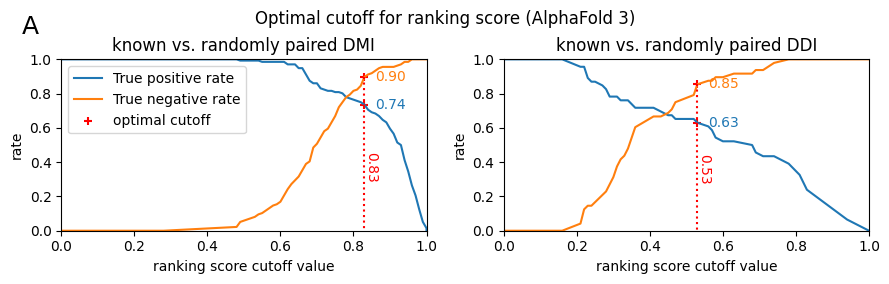

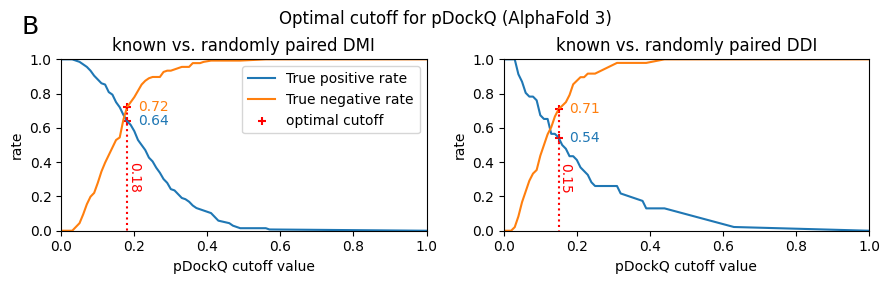

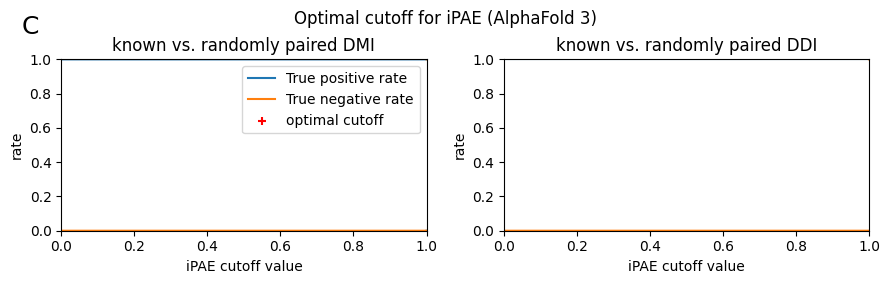

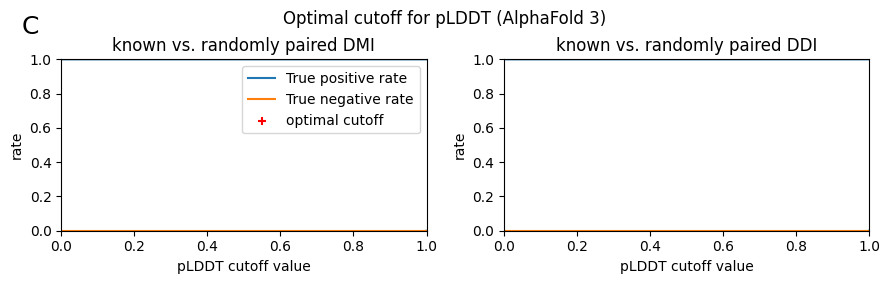

In [11]:
print("ranking score (AF3)")
plot_cutoff_plot(af_v="AF3",metric_column="ranking_score", label="ranking score", reverse=False, model_filter=True, rmsd_filter=False, save=False, letter="A")
print("pDockQ (AF3)")
plot_cutoff_plot(af_v="AF3",metric_column="pDockQ", label="pDockQ", reverse=False, model_filter=True, rmsd_filter=False, save=False, letter="B")

print("iPAE (AF3)")
plot_cutoff_plot(af_v="AF3",metric_column="iPAE", label="iPAE", reverse=False, model_filter=True, rmsd_filter=False, save=False, letter="C")

print("pLDDT (AF3)")
plot_cutoff_plot(af_v="AF3",metric_column="intf_avg_plddt", label="pLDDT", reverse=False, model_filter=True, rmsd_filter=False, save=False, letter="C")

model confidence (AF2)
DMI
	linear method: 0.80
	ROC minimizing: 0.69
	ROC maximizing: 0.80
DDI
	linear method: 0.58
	ROC minimizing: 0.38
	ROC maximizing: 0.66
pDockQ (AF2)
DMI
	linear method: 0.15
	ROC minimizing: 0.14
	ROC maximizing: 0.19
DDI
	linear method: 0.17
	ROC minimizing: 0.08
	ROC maximizing: 0.18
iPAE (AF2)
DMI
	linear method: 1.00
	ROC minimizing: 9.45
	ROC maximizing: 1.00
DDI
	linear method: 22.36
	ROC minimizing: 22.06
	ROC maximizing: 1.00
pLDDT (AF2)
DMI
	linear method: 85.80
	ROC minimizing: 85.80
	ROC maximizing: 88.90
DDI
	linear method: 84.17
	ROC minimizing: 69.77
	ROC maximizing: 84.17


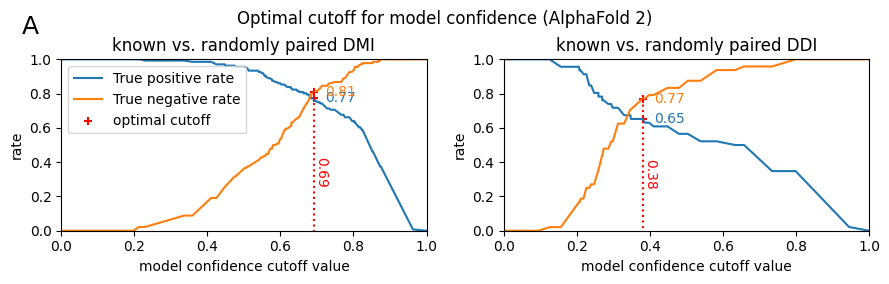

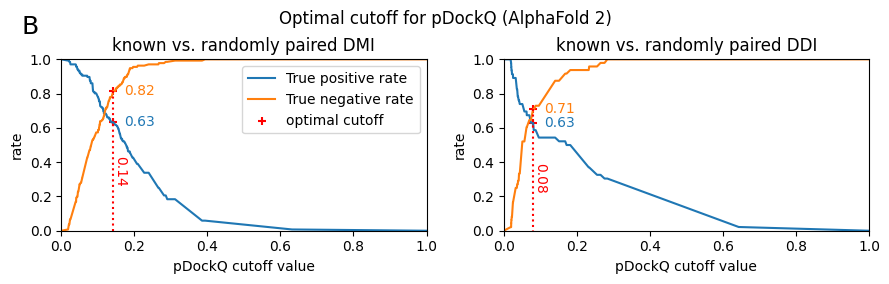

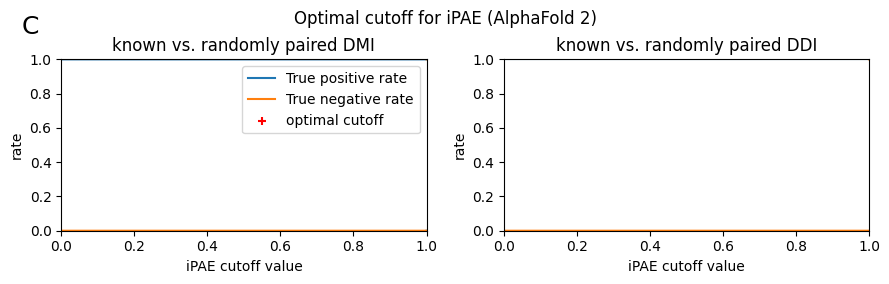

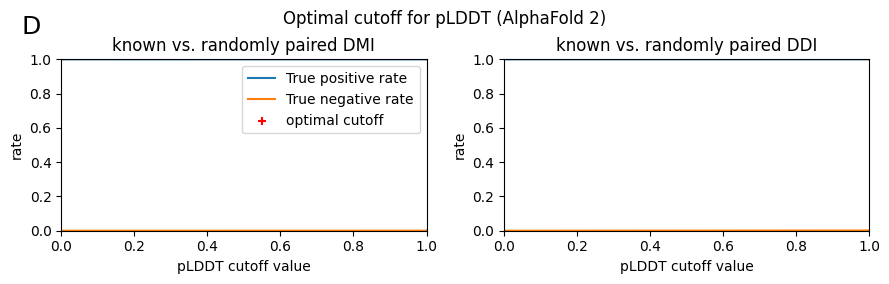

In [14]:
print("model confidence (AF2)")
plot_cutoff_plot(af_v="AF2",metric_column="model_confidence", label="model confidence", reverse=False, model_filter=True, rmsd_filter=False, save=True, letter="A")
print("pDockQ (AF2)")
plot_cutoff_plot(af_v="AF2",metric_column="pDockQ", label="pDockQ", reverse=False, model_filter=True, rmsd_filter=False, save=True, letter="B")


print("iPAE (AF2)")
plot_cutoff_plot(af_v="AF2",metric_column="iPAE", label="iPAE", reverse=False, model_filter=True, rmsd_filter=False, save=False, letter="C")

print("pLDDT (AF2)")
plot_cutoff_plot(af_v="AF2",metric_column="intf_avg_plddt", label="pLDDT", reverse=False, model_filter=True, rmsd_filter=False, save=False, letter="D")

DMI
	Optimal cutoff: 5.05
	tpr+(1-fpr): 5.05
	√tpr²+(1-fpr)²: 2.60
DDI
	Optimal cutoff: 15.70
	tpr+(1-fpr): 12.30
	√tpr²+(1-fpr)²: 11.80


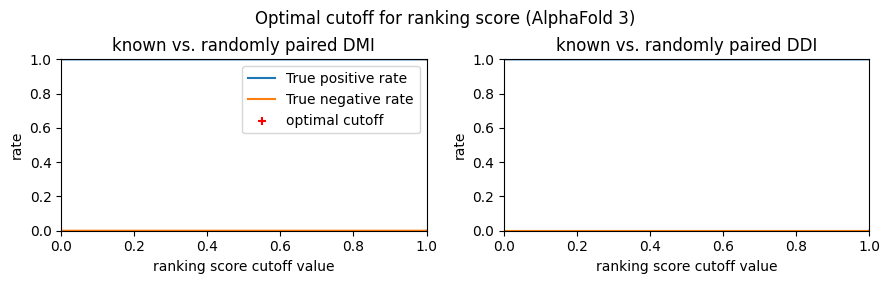

In [ ]:
plot_cutoff_plot(af_v="AF3",metric_column="iPAE", label="ranking score", reverse=True, model_filter=True, rmsd_filter=False, save=False, letter=None)

In [ ]:
print("model confidence (AF2)")
plot_cutoff_plot(af_v="AF2",metric_column="model_confidence", label="model confidence", reverse=False, model_filter=True, rmsd_filter=False, save=True, letter="A")
print("pDockQ (AF2)")
plot_cutoff_plot(af_v="AF2",metric_column="pDockQ", label="pDockQ", reverse=False, model_filter=True, rmsd_filter=False, save=True, letter="B")

{'bodies': [<matplotlib.collections.FillBetweenPolyCollection at 0x1c52ba8aa20>,
 'cmaxes': <matplotlib.collections.LineCollection at 0x1c52b9cde20>,
 'cmins': <matplotlib.collections.LineCollection at 0x1c52b75c320>,
 'cbars': <matplotlib.collections.LineCollection at 0x1c52ba514c0>}

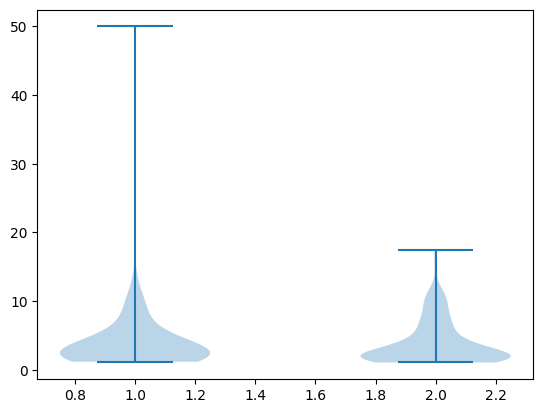

In [15]:
d = dataAF[(dataAF["benchmark_set"] == "known_DMI") & (dataAF["model_id"] == "ranked_0")]
plt.violinplot([d["iPAE_AF2"], d["iPAE_AF3"]])

### 4 AF3 ranking score stats

In [ ]:
print(np.unique(dataAF["has_clash"]))

[0.]


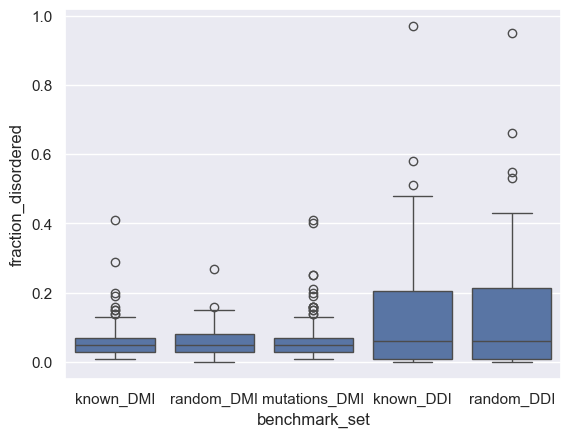

In [ ]:
def plot_af3_ranking_score_stats(model_filter: bool, save:bool):
    ax = plt.subplot()
    data_mask = np.full(len(dataAF), True)
    if model_filter:
        data_mask &= (dataAF["model_id"] == "ranked_0")


    d = {b:dataAF[(dataAF["benchmark_set"] == b) & data_mask] for b in ["known_DMI", "random_DMI", "mutations_DMI", "known_DDI", "random_DDI"]}
    #display(d)

    sns.set_theme()
    sns.boxplot(dataAF[data_mask], x="benchmark_set", y="fraction_disordered", ax=ax)
    plt.show()

plot_af3_ranking_score_stats(model_filter=True, save=False)

In [ ]:
plt.violinplot([dataAF[(dataAF["benchmark_set"] == "known_DMI") & (dataAF["model_id"] == "ranked_0")], dataAF[(dataAF["benchmark_set"] == "knwon") & (dataAF["model_id"] == "ranked_0")]])

In [ ]:
plt.violinplot([, [] ])

### 5 correlation

In [ ]:
def get_correlation(af_v: Literal["AF2", "AF3"], rank_filter: None|Literal["best_ranked", "RMSD", "RMSD_peptide", "DockQ"]):
    data_mask = True
    if rank_filter == "best_ranked":
        data_mask = data_mask & (dataAF[f"score_rank"] == 1)
    elif rank_filter is not None:
        data_mask = data_mask & (dataAF[f"{rank_filter}_rank_{af_v}"] == 1)

    def _get_corr():
        pass

    df = []
    for c in dataAF.columns:
        if not pd.api.types.is_numeric_dtype(dataAF[c].dtype):
            continue
        af_v_opposite = "AF2" if af_v == "AF3" else "AF3" 
        if af_v_opposite in c:
            continue
        d1 = dataAF[(dataAF["benchmark_set"] == "known_DMI") & data_mask].dropna(subset=[c, f"RMSD_all_atom_peptide_{af_v}"])
        corrDMI = None
        if len(np.unique(d1[c])) > 1:
            corrDMI = np.corrcoef(d1[f"RMSD_all_atom_peptide_{af_v}"], d1[c])[1,0]

        d2 = dataAF[(dataAF["benchmark_set"] == "known_DDI") & data_mask].dropna(subset=[c, f"RMSD_all_atom_peptide_{af_v}"])
        corrDDI = None
        if len(np.unique(d2[c])) > 1:
            corrDDI = np.corrcoef(d2[f"RMSD_all_atom_peptide_{af_v}"], d2[c])[1,0]
        df.append({"column": c, "n DMI": len(d1), "n DDI": len(d2), "DMI correlation": f"{corrDMI:1.3f}" if corrDMI is not None else None,  "DDI correlation": f"{corrDDI:1.3f}" if corrDDI is not None else None})
    return pd.DataFrame(df)
    
get_correlation("AF2", rank_filter="best_ranked")

,column,n DMI,n DDI,DMI correlation,DDI correlation
0,chainA_length,136,46,0.059,0.268
1,chainB_length,136,46,0.022,-0.019
2,chainA_start,136,46,0.084,-0.024
3,chainA_end,136,46,0.101,0.110
4,chainB_start,136,46,-0.089,-0.025
5,chainB_end,136,46,-0.089,-0.078
6,num_mutations,0,0,None,None
7,fraction_disordered,136,46,-0.086,-0.034
8,has_clash,136,46,None,None
9,iptm,136,46,-0.404,-0.609


### 6 AUROC between normalizations

In [ ]:
def get_auroc_normalizations(af_v: Literal["AF2", "AF3"], row_comparison: Literal["known_DMI|mutations1_DMI", "known_DMI|mutations2_DMI", "known_DMI|random_DMI", "known_DDI|random_DDI"], rank_filter: None|str|Literal["best_ranked", "RMSD", "RMSD_peptide", "DockQ"]):

    def _get_auroc(tr: pd.Series, fa: pd.Series, reverse: bool = False):
        y_true = [1]*len(tr) + [0]*len(fa) if not reverse else [0]*len(tr) + [1]*len(fa)
        y_score = tr.to_list() + fa.to_list()
        return roc_auc_score(y_true, y_score)
    
    def _norm_metric(rows: pd.DataFrame, metric_column: str, norm_column: str|None) -> pd.Series:
        if norm_column is None:
            return rows[metric_column].dropna()
        rows = rows.dropna(subset=[metric_column, norm_column]).copy()
        rows[norm_column] = rows[norm_column].replace(0, np.inf)
        return (rows[metric_column] / rows[norm_column]).replace([np.inf, -np.inf], 0).fillna(value=0)
        
    
    metric_columns = [("Interface distance", "min_distance", "tab:blue", True),
    ("Interface area", "buried_area", "tab:orange"),
    ("Salt bridges", "salt_bridges", "tab:green"),
    ("Hydrophobic interactions", "hydrophobic_interactions", "tab:red"),
    ("Hydrogen bonds", "hbonds", "tab:purple"),
    ]

    metric_columns = [[x[0], x[1] + "_"+af_v, x[2] , x[3] if len(x) >= 4 else False] for x in metric_columns]

    rows_sets = {
        "known_DMI": dataAF[dataAF["benchmark_set"] == "known_DMI"],
        "known_DDI": dataAF[dataAF["benchmark_set"] == "known_DDI"],
        "mutations1_DMI": dataAF[dataAF["num_mutations"] == 1],
        "mutations2_DMI": dataAF[dataAF["num_mutations"] == 2],
        "random_DMI": dataAF[dataAF["benchmark_set"] == "random_DMI"],
        "random_DDI": dataAF[dataAF["benchmark_set"] == "random_DDI"],
    }
    if rank_filter == "best_ranked":
        rows_sets = {lbl: df[df["score_rank"] == 1] for lbl, df in rows_sets.items()}
    elif rank_filter is not None:
        rows_sets = {lbl: df[((df[f"{rank_filter}_rank_{af_v}"].isna()) & (df["score_rank"] == 1)) | (df[f"{rank_filter}_rank_{af_v}"] == 1)] for lbl, df in rows_sets.items()}

    df = []
    for label, metric_column, color, reverse in metric_columns[1:]:
        d = {"metric": label}
        for norm_column in [None, 
                            f"buried_area_{af_v}", 
                            f"num_chainA_intf_res_{af_v}",  
                            f"num_chainB_intf_res_{af_v}",  
                            f"num_res_res_contact_{af_v}",  
                            f"num_atom_atom_contact_{af_v}"]:
            rows_true_normed = _norm_metric(rows=rows_sets[row_comparison.split("|")[0]], metric_column=metric_column, norm_column=norm_column)
            rows_false_normed = _norm_metric(rows=rows_sets[row_comparison.split("|")[1]], metric_column=metric_column, norm_column=norm_column)
            d[norm_column] = _get_auroc(rows_true_normed, rows_false_normed, reverse=reverse)
        df.append(d)
    return pd.DataFrame(df).round(3)

display(get_auroc_normalizations(af_v="AF2", row_comparison="known_DMI|random_DMI", rank_filter="best_ranked"))
display(get_auroc_normalizations(af_v="AF2", row_comparison="known_DDI|random_DDI", rank_filter="best_ranked"))


,metric,None,buried_area_AF2,num_chainA_intf_res_AF2,num_chainB_intf_res_AF2,num_res_res_contact_AF2,num_atom_atom_contact_AF2
0,Interface area,0.625,0.500,0.431,0.563,0.341,0.331
1,Salt bridges,0.581,0.572,0.564,0.578,0.564,0.565
2,Hydrophobic interactions,0.647,0.604,0.589,0.615,0.567,0.539
3,Hydrogen bonds,0.671,0.627,0.608,0.634,0.596,0.580


,metric,None,buried_area_AF2,num_chainA_intf_res_AF2,num_chainB_intf_res_AF2,num_res_res_contact_AF2,num_atom_atom_contact_AF2
0,Interface area,0.639,0.510,0.495,0.609,0.414,0.471
1,Salt bridges,0.593,0.551,0.556,0.567,0.546,0.537
2,Hydrophobic interactions,0.574,0.489,0.481,0.529,0.466,0.474
3,Hydrogen bonds,0.634,0.581,0.597,0.596,0.565,0.555


In [ ]:
display(get_auroc_normalizations(af_v="AF3", row_comparison="known_DMI|random_DMI", rank_filter="best_ranked"))
display(get_auroc_normalizations(af_v="AF3", row_comparison="known_DDI|random_DDI", rank_filter="best_ranked"))

,metric,None,buried_area_AF3,num_chainA_intf_res_AF3,num_chainB_intf_res_AF3,num_res_res_contact_AF3,num_atom_atom_contact_AF3
0,Interface area,0.545,0.500,0.439,0.508,0.426,0.364
1,Salt bridges,0.568,0.569,0.560,0.570,0.566,0.562
2,Hydrophobic interactions,0.601,0.590,0.583,0.581,0.574,0.541
3,Hydrogen bonds,0.673,0.672,0.662,0.662,0.665,0.653


,metric,None,buried_area_AF3,num_chainA_intf_res_AF3,num_chainB_intf_res_AF3,num_res_res_contact_AF3,num_atom_atom_contact_AF3
0,Interface area,0.591,0.500,0.499,0.591,0.397,0.431
1,Salt bridges,0.521,0.488,0.493,0.490,0.478,0.472
2,Hydrophobic interactions,0.647,0.651,0.651,0.663,0.650,0.646
3,Hydrogen bonds,0.648,0.618,0.616,0.626,0.599,0.591


### 7 Rank Analysis

In [ ]:
def compare_ranks(af_v: Literal["AF2", "AF3"], set_: Literal["DMI", "DDI"], c1: str, c2: str, filter_c: Literal[1, 2]):
    if c1 != "score_rank":
        c1 = f"{c1}_{af_v}"
    if c2 != "score_rank":
        c2 = f"{c2}_{af_v}"
    _merge = pd.merge(
        left=dataAF[(dataAF["benchmark_set"] == f"known_{set_}")],
        right=dataAF[(dataAF["benchmark_set"] == f"known_{set_}")],
        left_on=["prediction_name", "benchmark_set", c1],
        right_on=["prediction_name", "benchmark_set", c2],
        how="inner",
        suffixes=[f"_c1", f"_c2"]
    )
    return _merge[_merge[f"{c2}_c2" if filter_c == 1 else f"{c1}_c1"] == 1][["prediction_name", "benchmark_set", f"model_id_c1", f"model_id_c2", f"{c1}_c1", f"{c2}_c2", f"RMSD_all_atom_peptide_{af_v}_c1", f"RMSD_all_atom_peptide_{af_v}_c2", f"RMSD_all_atom_{af_v}_c1", f"RMSD_all_atom_{af_v}_c2", f"DockQ_{af_v}_c1", f"DockQ_{af_v}_c2"]]

def compare_best_with_worst(af_v: Literal["AF2", "AF3"], set_: Literal["DMI", "DDI"]):
    _merge = pd.merge(
        left=dataAF[(dataAF["benchmark_set"] == f"known_{set_}")],
        right=dataAF[(dataAF["benchmark_set"] == f"known_{set_}")],
        left_on=["prediction_name", "benchmark_set"],
        right_on=["prediction_name", "benchmark_set"],
        how="inner",
        suffixes=["_c1", "_c2"]
    )
    return _merge[(_merge["score_rank_c1"] == 1) & (_merge["score_rank_c2"] == 5)][["prediction_name", "benchmark_set", f"model_id_c1", f"model_id_c2",f"RMSD_all_atom_peptide_{af_v}_c1", f"RMSD_all_atom_peptide_{af_v}_c2", f"RMSD_all_atom_{af_v}_c1", f"RMSD_all_atom_{af_v}_c2", f"DockQ_{af_v}_c1", f"DockQ_{af_v}_c2"]]

def compare(af_v: Literal["AF2", "AF3"], set_: Literal["DMI", "DDI"], c2: Literal["RMSD", "RMSD_peptide", "DockQ"], violinplot: bool):
    match c2:
        case "RMSD": cc2 = f"RMSD_all_atom_{af_v}"
        case "RMSD_peptide": cc2 = f"RMSD_all_atom_peptide_{af_v}"
        case "DockQ": cc2 = f"DockQ_{af_v}"
        case _: raise RuntimeError()
    print(f"{af_v} {set_} {c2}")
    d = {}
    for label, rank_column in {"ranking_score": "score_rank", "pDockQ": "pDockQ_rank", "iPAE": "iPAE_rank", "pLDDT": "intf_avg_plddt_rank"}.items():
        df = (compare_ranks(af_v=af_v, set_=set_, c1=rank_column, c2=f"{c2}_rank", filter_c=1))

        m = np.abs(df[f"{cc2}_c1"].to_numpy() - df[f"{cc2}_c2"].to_numpy())
        median = np.median(m)
        q3 = np.quantile(m, q=0.75)
        max = np.max(m)
        d[label] = m
        print("\t%s median Δ%s = %1.3f Å (Q3 %1.3f Å, max %1.3f Å)" % (label, c2, median, q3, max))
    delta_rmsd = compare_best_with_worst(af_v, set_)
    delta_rmsd = delta_rmsd[f"{cc2}_c1"].to_numpy() - delta_rmsd[f"{cc2}_c2"].to_numpy()
    max = np.max(np.abs(delta_rmsd))
    median = np.median(np.abs(delta_rmsd))
    print("\tΔ%s best vs. worst model median: %1.3f (max %1.3f)" % (c2, median, max))
    if violinplot:
        sns.violinplot(d, bw_adjust=0.1, cut=0)
        plt.show()

AF3 DMI RMSD
	ranking_score median ΔRMSD = 0.074 Å (Q3 0.209 Å, max 6.342 Å)
	pDockQ median ΔRMSD = 0.078 Å (Q3 0.260 Å, max 31.304 Å)
	iPAE median ΔRMSD = 0.076 Å (Q3 0.187 Å, max 29.428 Å)
	pLDDT median ΔRMSD = 0.056 Å (Q3 0.175 Å, max 6.342 Å)
	ΔRMSD best vs. worst model median: 0.122 (max 26.535)
AF3 DMI RMSD_peptide
	ranking_score median ΔRMSD_peptide = 0.171 Å (Q3 0.555 Å, max 26.521 Å)
	pDockQ median ΔRMSD_peptide = 0.229 Å (Q3 0.659 Å, max 42.647 Å)
	iPAE median ΔRMSD_peptide = 0.174 Å (Q3 0.534 Å, max 31.280 Å)
	pLDDT median ΔRMSD_peptide = 0.174 Å (Q3 0.494 Å, max 41.257 Å)
	ΔRMSD_peptide best vs. worst model median: 0.365 (max 42.647)


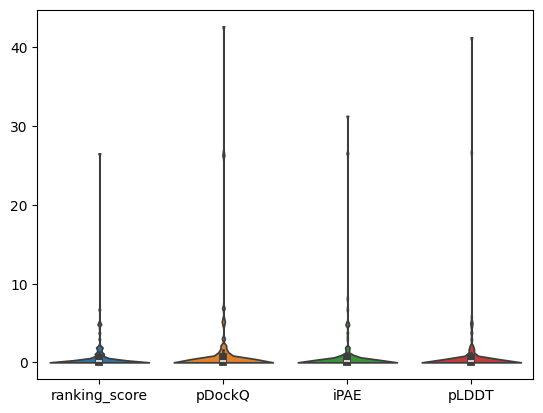

AF3 DMI DockQ
	ranking_score median ΔDockQ = 0.011 Å (Q3 0.032 Å, max 0.931 Å)
	pDockQ median ΔDockQ = 0.016 Å (Q3 0.037 Å, max 0.931 Å)
	iPAE median ΔDockQ = 0.010 Å (Q3 0.031 Å, max 0.931 Å)
	pLDDT median ΔDockQ = 0.009 Å (Q3 0.033 Å, max 0.931 Å)
	ΔDockQ best vs. worst model median: 0.022 (max 0.931)


In [ ]:
compare("AF3", "DMI", "RMSD", violinplot=False)
compare("AF3", "DMI", "RMSD_peptide", violinplot=True)
compare("AF3", "DMI", "DockQ", violinplot=False)

AF2 DMI RMSD
	ranking_score median ΔRMSD = 0.047 Å (Q3 0.204 Å, max 2.929 Å)
	pDockQ median ΔRMSD = 0.056 Å (Q3 0.222 Å, max 1.812 Å)
	iPAE median ΔRMSD = 0.044 Å (Q3 0.212 Å, max 1.812 Å)
	pLDDT median ΔRMSD = 0.049 Å (Q3 0.205 Å, max 2.623 Å)
	ΔRMSD best vs. worst model median: 0.141 (max 10.929)
AF2 DMI RMSD_peptide
	ranking_score median ΔRMSD_peptide = 0.092 Å (Q3 0.470 Å, max 14.374 Å)
	pDockQ median ΔRMSD_peptide = 0.108 Å (Q3 0.682 Å, max 8.588 Å)
	iPAE median ΔRMSD_peptide = 0.088 Å (Q3 0.399 Å, max 9.500 Å)
	pLDDT median ΔRMSD_peptide = 0.120 Å (Q3 0.643 Å, max 12.778 Å)
	ΔRMSD_peptide best vs. worst model median: 0.596 (max 180.110)


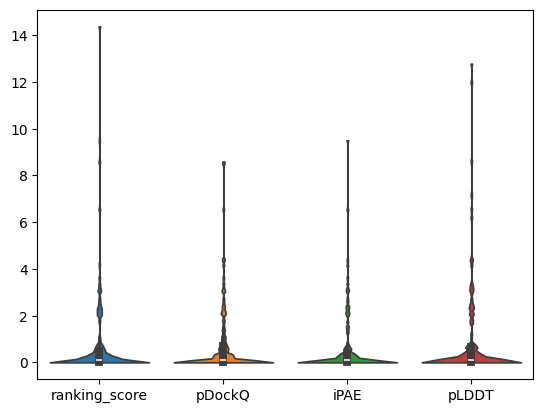

AF2 DMI DockQ
	ranking_score median ΔDockQ = 0.009 Å (Q3 0.029 Å, max 0.502 Å)
	pDockQ median ΔDockQ = 0.009 Å (Q3 0.036 Å, max 0.502 Å)
	iPAE median ΔDockQ = 0.009 Å (Q3 0.030 Å, max 0.444 Å)
	pLDDT median ΔDockQ = 0.009 Å (Q3 0.034 Å, max 0.502 Å)
	ΔDockQ best vs. worst model median: 0.024 (max 0.890)


In [ ]:
compare("AF2", "DMI", "RMSD", violinplot=False)
compare("AF2", "DMI", "RMSD_peptide", violinplot=True)
compare("AF2", "DMI", "DockQ", violinplot=False)

In [ ]:
np.median(dataAF[(dataAF["benchmark_set"] == "known_DDI") & (dataAF["RMSD_peptide_rank_AF2"] == 1)]["RMSD_all_atom_peptide_AF2"])

9.535327911376953

AF3 DDI RMSD
	ranking_score median ΔRMSD = 0.375 Å (Q3 3.121 Å, max 13.243 Å)
	pDockQ median ΔRMSD = 0.363 Å (Q3 2.293 Å, max 13.243 Å)
	iPAE median ΔRMSD = 0.303 Å (Q3 1.244 Å, max 17.320 Å)
	pLDDT median ΔRMSD = 0.235 Å (Q3 1.280 Å, max 13.243 Å)
	ΔRMSD best vs. worst model median: 0.551 (max 17.161)
AF3 DDI RMSD_peptide
	ranking_score median ΔRMSD_peptide = 1.244 Å (Q3 8.494 Å, max 23.178 Å)
	pDockQ median ΔRMSD_peptide = 0.787 Å (Q3 7.231 Å, max 48.547 Å)
	iPAE median ΔRMSD_peptide = 0.852 Å (Q3 3.227 Å, max 49.828 Å)
	pLDDT median ΔRMSD_peptide = 0.789 Å (Q3 3.227 Å, max 48.547 Å)
	ΔRMSD_peptide best vs. worst model median: 2.322 (max 49.929)


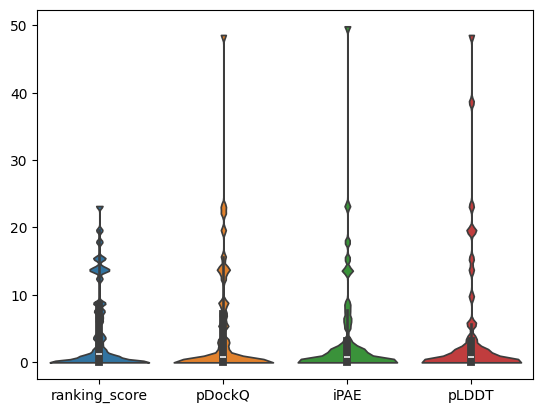

AF3 DDI DockQ
	ranking_score median ΔDockQ = 0.014 Å (Q3 0.040 Å, max 0.153 Å)
	pDockQ median ΔDockQ = 0.014 Å (Q3 0.036 Å, max 0.153 Å)
	iPAE median ΔDockQ = 0.021 Å (Q3 0.040 Å, max 0.153 Å)
	pLDDT median ΔDockQ = 0.014 Å (Q3 0.040 Å, max 0.144 Å)
	ΔDockQ best vs. worst model median: 0.018 (max 0.770)


In [ ]:
compare("AF3", "DDI", "RMSD", violinplot=False)
compare("AF3", "DDI", "RMSD_peptide", violinplot=True)
compare("AF3", "DDI", "DockQ", violinplot=False)

AF2 DDI RMSD
	ranking_score median ΔRMSD = 0.065 Å (Q3 0.435 Å, max 16.985 Å)
	pDockQ median ΔRMSD = 0.170 Å (Q3 1.153 Å, max 22.552 Å)
	iPAE median ΔRMSD = 0.296 Å (Q3 1.425 Å, max 15.353 Å)
	pLDDT median ΔRMSD = 0.240 Å (Q3 1.854 Å, max 22.552 Å)
	ΔRMSD best vs. worst model median: 0.895 (max 21.464)
AF2 DDI RMSD_peptide
	ranking_score median ΔRMSD_peptide = 0.250 Å (Q3 1.295 Å, max 46.546 Å)
	pDockQ median ΔRMSD_peptide = 0.349 Å (Q3 3.781 Å, max 49.210 Å)
	iPAE median ΔRMSD_peptide = 0.784 Å (Q3 4.715 Å, max 46.546 Å)
	pLDDT median ΔRMSD_peptide = 0.595 Å (Q3 5.238 Å, max 49.451 Å)
	ΔRMSD_peptide best vs. worst model median: 3.054 (max 56.744)


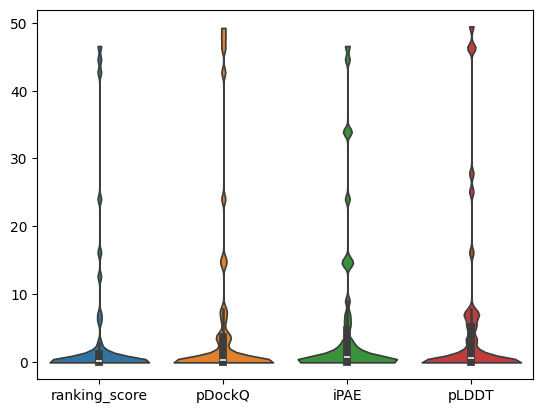

AF2 DDI DockQ
	ranking_score median ΔDockQ = 0.006 Å (Q3 0.019 Å, max 0.768 Å)
	pDockQ median ΔDockQ = 0.009 Å (Q3 0.031 Å, max 0.768 Å)
	iPAE median ΔDockQ = 0.013 Å (Q3 0.034 Å, max 0.755 Å)
	pLDDT median ΔDockQ = 0.007 Å (Q3 0.022 Å, max 0.462 Å)
	ΔDockQ best vs. worst model median: 0.019 (max 0.816)


In [ ]:
compare("AF2", "DDI", "RMSD", violinplot=False)
compare("AF2", "DDI", "RMSD_peptide", violinplot=True)
compare("AF2", "DDI", "DockQ", violinplot=False)

In [ ]:
print("DMI")
for label, rank_column in {"ranking_score": "score_rank", "pDockQ": "pDockQ_rank", "iPAE": "iPAE_rank", "pLDDT": "intf_avg_plddt_rank"}.items():
    df = (compare_ranks(af_v="AF2", set_="DMI", c1=rank_column, c2="RMSD_peptide_rank", filter_c=1))
    print("%s median ΔRMSD = %1.3f Å" % (label, np.median(np.abs(df["RMSD_all_atom_peptide_AF2_c1"].to_numpy() - df["RMSD_all_atom_peptide_AF2_c2"].to_numpy()))))
print("DDI")
for label, rank_column in {"ranking_score": "score_rank", "pDockQ": "pDockQ_rank", "iPAE": "iPAE_rank", "pLDDT": "intf_avg_plddt_rank"}.items():
    df = (compare_ranks(af_v="AF2", set_="DDI", c1=rank_column, c2="RMSD_rank", filter_c=1))
    print("%s median ΔRMSD = %1.3f Å" % (label, np.median(np.abs(df["RMSD_all_atom_AF2_c1"].to_numpy() - df["RMSD_all_atom_AF2_c2"].to_numpy()))))

DMI
ranking_score median ΔRMSD = 0.092 Å
pDockQ median ΔRMSD = 0.108 Å
iPAE median ΔRMSD = 0.088 Å
pLDDT median ΔRMSD = 0.120 Å
DDI
ranking_score median ΔRMSD = 0.065 Å
pDockQ median ΔRMSD = 0.170 Å
iPAE median ΔRMSD = 0.296 Å
pLDDT median ΔRMSD = 0.240 Å


In [ ]:
dataAF

,model_preset,benchmark_set,prediction_name,model_id,ranking_score_AF3,chainA_length,chainB_length,chainA_id,chainB_id,chainA_start,...,salt_bridges_AF2,hbonds_AF2,hydrophobic_interactions_AF2,RMSD_rank_AF2,RMSD_peptide_rank_AF2,DockQ_rank_AF2,intf_avg_plddt_rank_AF2,chainB_intf_avg_plddt_rank_AF2,pDockQ_rank_AF2,iPAE_rank_AF2
0,alphafold3,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_0,0.97,312,5,A,B,165,...,0,9,0,2,2,3,1,1,1,1
1,alphafold3,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_1,0.97,312,5,A,B,165,...,0,9,0,3,1,2,2,2,2,2
2,alphafold3,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_2,0.96,312,5,A,B,165,...,0,10,3,1,3,1,3,3,3,3
3,alphafold3,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_3,0.96,312,5,A,B,165,...,0,2,0,4,4,4,4,4,4,4
4,alphafold3,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_4,0.96,312,5,A,B,165,...,0,2,9,5,5,5,5,5,5,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3165,alphafold3,random_DDI,D1PF18773_PF00071_2X19.D2PF00009_PF01873_2D74,ranked_0,0.36,60,113,B,B,392,...,3,7,56,1,<NA>,<NA>,4,4,2,1
3166,alphafold3,random_DDI,D1PF18773_PF00071_2X19.D2PF00009_PF01873_2D74,ranked_1,0.23,60,113,B,B,392,...,0,3,7,5,<NA>,<NA>,3,3,3,2
3167,alphafold3,random_DDI,D1PF18773_PF00071_2X19.D2PF00009_PF01873_2D74,ranked_2,0.22,60,113,B,B,392,...,1,2,11,4,<NA>,<NA>,5,5,5,3
3168,alphafold3,random_DDI,D1PF18773_PF00071_2X19.D2PF00009_PF01873_2D74,ranked_3,0.21,60,113,B,B,392,...,3,7,44,3,<NA>,<NA>,1,1,4,4
